# 非科技股表现与选股特征研究

研究区间：2026-07-01 至 2026-09-11。对比非科技股涨幅前100与同期全部非科技股。已包含数据读取、初步区间收益排名与行业分布统计；样本口径见统计单元格注释。按顺序运行以下单元格。

数据流程分为三层：
1. `原始数据/supermind行情数据拉取.ipynb` 只负责拉取并保存原始数据；
2. 进入篇章前直接完成一次共用大表预处理，统一合并个股行情、L2归属、五大板块映射和每日总市值，并生成共同研究样本；
3. 行业篇、因子篇、形态篇仅在本篇确有新增数据需求时，在篇章内部完成相应计算或合并。


In [1]:
from pathlib import Path
import pandas as pd

PROJECT_DIR = Path(r"D:\latitude_enterpise\tesk14_7月1日后非科技股表现和选股喜好研究报告")
DATA_DIR = PROJECT_DIR / "原始数据"
RESEARCH_START_DATE = pd.Timestamp("2026-07-01")  # 正式研究区间起点
END_DATE = pd.Timestamp("2026-09-11")
pd.set_option("display.max_columns", 30)

## 1. 日行情与实际预热长度

数据起点从文件读取，不以请求起点代替实际覆盖。当前行情首日为2026-05-06，研究起点为2026-07-01；5月6日至6月30日共有39个交易日。

研究首日之前最多有39条日线：20日、30日窗口可供历史足够的股票使用；严格使用前40日或前60日的指标无法在研究首日获得完整窗口。包含7月1日当天的40条收盘价均值与使用前40日历史不同；40日区间收益还需要41个价格点。

下方按研究首日有行情的股票检查历史长度。“有效交易记录”定义为未停牌且收盘价大于0，不代表所有指标的有效观测数；收益、成交量等指标仍须按自身字段和滞后要求检查。新股和停牌股票可能不足窗口，不缩短窗口或填充伪造历史。

先在完整历史上计算滚动指标，再截取研究区间。价格为前复权口径，`money`为成交额（元）。

In [2]:
stock_code_name = pd.read_pickle(DATA_DIR / "ths_stock_code_name_20260911.pkl.gz")
stock_name_map = stock_code_name.set_index("code")["name"].to_dict()
stock_name_map.update({
    "000004.XSHE": "国华退", "000638.XSHE": "*ST万方",
    "002808.XSHE": "恒久退", "002898.XSHE": "赛隆退",
    "300029.XSHE": "天龙退",
    "600193.XSHG": "退市创兴", "600421.XSHG": "退市华嵘",
    "600599.XSHG": "退市熊猫", "600608.XSHG": "退市沪科",
    "600636.XSHG": "退市国化", "600696.XSHG": "退市岩石",
    "605081.XSHG": "退市太和", "688287.XSHG": "退市观典",
    "920305.XBSE": "云创退",
})

def add_stock_name(frame, code_column="code"):
    result = frame.copy()
    platform_code = (result[code_column].astype(str)
        .str.replace(r"\.SH$", ".XSHG", regex=True)
        .str.replace(r"\.SZ$", ".XSHE", regex=True)
        .str.replace(r"\.BJ$", ".XBSE", regex=True))
    names = platform_code.map(stock_name_map)
    assert names.notna().all(), f"存在未匹配股票名称：{result.loc[names.isna(), code_column].unique().tolist()}"
    result.insert(result.columns.get_loc(code_column) + 1, "股票名称", names.to_numpy())
    return result

prices = pd.read_pickle(DATA_DIR / "ths_daily_20260501_20260911_20260914_155525_940034.pkl.xz")
prices = add_stock_name(prices)
print(f"行情：{len(prices):,} 行，{prices['code'].nunique():,} 个代码")
print("日期范围：", prices["time"].min(), "至", prices["time"].max())
display(prices.head())

行情：509,027 行，5,576 个代码
日期范围： 2026-05-06 00:00:00 至 2026-09-11 00:00:00


,time,code,股票名称,open,high,low,close,pre_close,volume,money,factor,paused,return_1d
0,2026-05-06,000001.XSHE,平安银行,11.14,11.14,10.94,11.00,11.13,121638755.0,1.380731e+09,140.2909,0.0,-0.011680
1,2026-05-07,000001.XSHE,平安银行,11.01,11.03,10.94,11.01,11.00,93695806.0,1.062755e+09,140.2909,0.0,0.000909
2,2026-05-08,000001.XSHE,平安银行,10.98,11.06,10.94,10.94,11.01,79881986.0,9.057378e+08,140.2909,0.0,-0.006358
3,2026-05-11,000001.XSHE,平安银行,10.93,10.95,10.80,10.92,10.94,93186521.0,1.047435e+09,140.2909,0.0,-0.001828
4,2026-05-12,000001.XSHE,平安银行,10.92,11.00,10.85,10.89,10.92,102903842.0,1.158242e+09,140.2909,0.0,-0.002747


In [3]:
DATA_START_DATE = prices["time"].min()
warmup_prices = prices.loc[prices["time"] < RESEARCH_START_DATE]
warmup_trade_days = warmup_prices["time"].nunique()
start_codes = prices.loc[prices["time"].eq(RESEARCH_START_DATE), "code"]
warmup_coverage = pd.DataFrame({
    "历史日线数": warmup_prices.groupby("code", observed=True).size(),
    "有效交易记录数": warmup_prices.loc[
        warmup_prices["paused"].eq(0) & warmup_prices["close"].gt(0)
    ].groupby("code", observed=True).size(),
}).reindex(start_codes).fillna(0).astype(int)

print("实际数据起点：", DATA_START_DATE)
print("研究前预热交易日数：", warmup_trade_days)
display(pd.DataFrame({
    "所需前置记录数": [20, 30, 39, 40, 60],
    "历史日线足够的股票数": [warmup_coverage["历史日线数"].ge(w).sum() for w in [20, 30, 39, 40, 60]],
    "有效交易记录足够的股票数": [warmup_coverage["有效交易记录数"].ge(w).sum() for w in [20, 30, 39, 40, 60]],
}))

实际数据起点： 2026-05-06 00:00:00
研究前预热交易日数： 39


,所需前置记录数,历史日线足够的股票数,有效交易记录足够的股票数
0,20,5519,5508
1,30,5513,5496
2,39,5506,5401
3,40,0,0
4,60,0,0


## 2. 每日二级、三级行业归属

L2、L3分别读取同批次的独立数据包，保留完整日期、缺失和多归属。每个part文件都可直接用pd.read_pickle读取。

industry_l2包含time、code、symbol、l2_code、l2_name；industry_l3对应使用l3_code、l3_name。

当前L2有90个已映射行业；L3目录有232个行业，其中231个有成员记录。600052.XSHG每天有“本地生活服务”和“热力”两个L3归属，因此暂不合并两层级，后续连接行情需明确多归属处理口径。

In [4]:
INDUSTRY_PREFIX = "ths_industry_20260501_20260911_20260916_093643_096184"
industry_l2 = pd.read_pickle(DATA_DIR / f"{INDUSTRY_PREFIX}_l2_part001.pkl.gz")
industry_l3 = pd.read_pickle(DATA_DIR / f"{INDUSTRY_PREFIX}_l3_part001.pkl.gz")
industry_l2 = add_stock_name(industry_l2)
industry_l3 = add_stock_name(industry_l3)

for level, frame in [("l2", industry_l2), ("l3", industry_l3)]:
    print(f"{level.upper()}：{len(frame):,} 行，{frame[level + '_code'].nunique()} 个已映射行业")
    print("日期范围：", frame["time"].min(), "至", frame["time"].max())
    display(frame.head())

L2：531,843 行，90 个已映射行业
日期范围： 2026-05-06 00:00:00 至 2026-09-11 00:00:00


,time,code,股票名称,symbol,l2_code,l2_name
0,2026-05-06,301172.XSHE,君逸数码,301172.SZ,T1004,IT服务
1,2026-05-06,002777.XSHE,久远银海,002777.SZ,T1004,IT服务
2,2026-05-06,603171.XSHG,税友股份,603171.SH,T1004,IT服务
3,2026-05-06,003005.XSHE,竞业达,003005.SZ,T1004,IT服务
4,2026-05-06,300496.XSHE,中科创达,300496.SZ,T1004,IT服务


L3：531,935 行，231 个已映射行业
日期范围： 2026-05-06 00:00:00 至 2026-09-11 00:00:00


,time,code,股票名称,symbol,l3_code,l3_name
0,2026-05-06,002076.XSHE,星光股份,002076.SZ,T080202,LED
1,2026-05-06,001326.XSHE,联域股份,001326.SZ,T080202,LED
2,2026-05-06,002638.XSHE,勤上股份,002638.SZ,T080202,LED
3,2026-05-06,603303.XSHG,得邦照明,603303.SH,T080202,LED
4,2026-05-06,002723.XSHE,小崧股份,002723.SZ,T080202,LED


## 3. 五大板块映射

保留原始映射，另按既定规则筛选唯一主归属：消费电子归科技，化学制品和能源金属归周期。双边标签不改变主归属。

In [5]:
sector_mapping_raw = pd.read_csv(PROJECT_DIR / "Runoff_inventory.csv")
trunk_mapping = {"消费电子": "科技", "化学制品": "周期", "能源金属": "周期"}
trunk_big5 = sector_mapping_raw["同花顺_l2"].map(trunk_mapping)
sector_mapping = sector_mapping_raw.loc[
    trunk_big5.isna() | sector_mapping_raw["big5_l1"].eq(trunk_big5)
].copy()
NON_TECH_SECTORS = ["消费", "周期", "金融", "医药"]

print(f"原始映射：{len(sector_mapping_raw)} 行；主归属映射：{len(sector_mapping)} 行")
display(sector_mapping.groupby("big5_l1", sort=False).size().rename("二级行业数").to_frame())
display(sector_mapping.head())

原始映射：93 行；主归属映射：90 行


,二级行业数
big5_l1,
科技,21
周期,33
消费,26
金融,4
医药,6


,同花顺_l2,big5_l2,big5_l1,big5_bilateral
0,半导体,硬科技与高端制造,科技,NaN
1,元件,硬科技与高端制造,科技,NaN
2,消费电子,硬科技与高端制造,科技,科技+消费
3,光学光电子,硬科技与高端制造,科技,NaN
4,电子化学品,硬科技与高端制造,科技,科技+周期


## 4. 季度财务原始表

统一使用20260915_170338_206984批次，避免重复读取另一批次的2025Q4资产负债表。`balance`和`income_sq`为按报告期索引的字典，例如`balance["2026q1"]`。

利润表为单季度口径。尚未按披露日期对齐，不能直接作为研究时点已知信息；2026Q2利润表存在报告日期晚于研究截止日的记录。

In [6]:
FINANCIAL_PREFIX = "ths_quarterly_2025q4_2026q2_20260915_170338_206984"
PERIODS = ["2025q4", "2026q1", "2026q2"]

balance = {
    period: pd.read_pickle(DATA_DIR / f"{FINANCIAL_PREFIX}_balance_{period}.pkl.gz")
    for period in PERIODS
}
income_sq = {
    period: pd.read_pickle(DATA_DIR / f"{FINANCIAL_PREFIX}_income_sq_{period}.pkl.gz")
    for period in PERIODS
}
for period in PERIODS:
    balance[period] = add_stock_name(balance[period], "balance_stat_symbol")
    income_sq[period] = add_stock_name(income_sq[period], "income_sq_stat_symbol")
display(pd.DataFrame({
    "资产负债表行数": {period: len(frame) for period, frame in balance.items()},
    "单季度利润表行数": {period: len(frame) for period, frame in income_sq.items()},
}))
display(balance["2026q1"].head())
display(income_sq["2026q1"].head())

,资产负债表行数,单季度利润表行数
2025q4,5575,5554
2026q1,5570,5570
2026q2,5571,5566


,balance_stat_id,balance_stat_symbol,股票名称,balance_stat_stat_date,balance_stat_report_date,balance_stat_stat_date__duplicate2,balance_stat_cash,balance_stat_tradable_financial_assets,balance_stat_notes_receivable,balance_stat_accounts_receivable,balance_stat_advance_payment,balance_stat_interest_receivable,balance_stat_dividends_receivable,balance_stat_receivable_other,balance_stat_inventory,...,balance_stat_current_liab_di,balance_stat_st_bond_payable,balance_stat_noncurrent_liab_di,balance_stat_guarantee_deposits,balance_stat_money_loan,balance_stat_receivables,balance_stat_short_term_financing_payable,balance_stat_accounts_payable,balance_stat_other_consolidated_income,balance_stat_lt_staff_salary_payable,balance_stat_other_equity_instrument,balance_stat_preferred_equity,balance_stat_perpetual_bond,balance_stat_change_id,balance_stat_reporttypecode
0,1868040800,000001.SZ,平安银行,2026-03-31,2026-04-25,2026-03-31,NaN,8.501310e+11,NaN,NaN,NaN,NaN,NaN,None,NaN,...,None,None,NaN,None,NaN,NaN,NaN,NaN,6.400000e+07,NaN,80000000000.0,NaN,80000000000.0,0,HBTZ
1,1867603610,000002.SZ,万科A,2026-03-31,2026-04-30,2026-03-31,6.049262e+10,6.709077e+07,6281646.51,1.064208e+10,1.803411e+10,NaN,2591627.29,None,3.656600e+11,...,None,None,NaN,None,NaN,NaN,NaN,NaN,-4.202638e+09,NaN,NaN,NaN,NaN,0,HBTZ
2,1868387679,000004.SZ,国华退,2026-03-31,2026-04-28,2026-03-31,9.703751e+07,NaN,548450.00,1.181356e+08,7.600099e+06,NaN,NaN,None,7.546257e+06,...,None,None,471532.49,None,NaN,NaN,NaN,NaN,2.225159e+07,NaN,NaN,NaN,NaN,0,HBTZ
3,1868041010,000006.SZ,深振业A,2026-03-31,2026-04-30,2026-03-31,2.614553e+09,1.041391e+08,NaN,4.174573e+07,1.420699e+06,NaN,NaN,None,1.034895e+10,...,None,None,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,HBTZ
4,1867603909,000007.SZ,全新好,2026-03-31,2026-04-29,2026-03-31,8.955333e+07,9.000000e+06,NaN,3.530274e+07,1.612355e+07,NaN,NaN,None,5.159507e+07,...,None,None,NaN,None,NaN,NaN,NaN,NaN,-1.784100e+06,NaN,NaN,NaN,NaN,0,HBTZ


,income_sq_stat_id,income_sq_stat_symbol,股票名称,income_sq_stat_stat_date,income_sq_stat_report_date,income_sq_stat_stat_date__duplicate2,income_sq_stat_overall_income,income_sq_stat_operating_income,income_sq_stat_interests_net_income,income_sq_stat_interests_income,income_sq_stat_interests_expenses,income_sq_stat_commi_net_income,income_sq_stat_charges_and_commissions_income,income_sq_stat_charges_and_commissions_expenses,income_sq_stat_other_business_income,...,income_sq_stat_spec_cond_desc,income_sq_stat_noncurrent_assets_dispose_gain,income_sq_stat_total_compre_income_atsopc,income_sq_stat_othr_ci_nonreclassi_into_gal,income_sq_stat_net_debt_or_na_chg_reclac,income_sq_stat_unclass_other_profit_share,income_sq_stat_classify_other_profit,income_sq_stat_will_reclassi_equity_method,income_sq_stat_saleable_fnncl_asset_fvc_gal,income_sq_stat_htm_saleable_fnncl_asset_gal,income_sq_stat_cash_flow_gal_valid_part,income_sq_stat_translation_reserve,income_sq_other6,income_sq_stat_other_compre_income_atms,income_sq_other3
0,1311789491,000001.SZ,平安银行,2026-03-31,2026-04-25,2026-03-31,3.527700e+10,3.527700e+10,22081000000.0,39895000000.0,17814000000.0,7362000000.0,8161000000.0,799000000.0,62000000.0,...,NULL,None,NaN,-2.600000e+07,NaN,NaN,-46000000.0,NaN,None,None,NaN,-19000000.0,NaN,NaN,NaN
1,1311947050,000002.SZ,万科A,2026-03-31,2026-04-30,2026-03-31,2.892789e+10,2.892789e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NULL,None,-6.335841e+09,-3.077198e+08,NaN,NaN,-75964850.7,NaN,None,None,NaN,-75964850.7,NaN,-19494435.14,NaN
2,1311947065,000004.SZ,国华退,2026-03-31,2026-04-28,2026-03-31,1.662275e+07,1.662275e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NULL,None,-6.388269e+06,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN
3,1311947180,000006.SZ,深振业A,2026-03-31,2026-04-30,2026-03-31,5.252034e+08,5.252034e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NULL,None,7.527444e+06,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN
4,1311789731,000007.SZ,全新好,2026-03-31,2026-04-29,2026-03-31,1.237553e+08,1.237553e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NULL,None,-2.170683e+06,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN


## 5. 覆盖记录

财务审计为累积保存，只读取同批次最后一份。L2和L3覆盖记录分别从各自表属性读取，industry_coverage用level区分层级。

记录包括股票数、行业目录数、未映射股票、多归属股票、空行业及股票范围外关系。目录原文保留在各表的attrs["directories"]中。

In [7]:
financial_coverage = pd.read_pickle(
    DATA_DIR / f"{FINANCIAL_PREFIX}_income_sq_2026q2_coverage_audit.pkl.gz"
)
industry_l2_coverage = pd.DataFrame(industry_l2.attrs["coverage_checks"])
industry_l3_coverage = pd.DataFrame(industry_l3.attrs["coverage_checks"])
industry_coverage = pd.concat([
    industry_l2_coverage.assign(level="l2"),
    industry_l3_coverage.assign(level="l3"),
], ignore_index=True)
price_missing_symbols = prices.attrs["missing_symbols"]

print("无行情返回代码数：", len(price_missing_symbols))
display(financial_coverage.groupby(["table", "period", "status"]).size().rename("代码数").to_frame())
print("L2覆盖记录：")
display(industry_l2_coverage.head())
print("L3覆盖记录：")
display(industry_l3_coverage.head())

无行情返回代码数： 248


代码数
table     period status                       
balance   2025q4 empty_after_single_retry  249
          2026q1 empty_after_single_retry  254
          2026q2 empty_after_single_retry  253
income_sq 2025q4 empty_after_single_retry  270
          2026q1 empty_after_single_retry  254
          2026q2 empty_after_single_retry  258

L2覆盖记录：


,date,stock_count,industry_count,empty_industries,empty_status,missing_symbols,multiple_symbols,outside_stock_universe
0,20260506,5760,90,[],empty_unverified,"[430017.BJ, 430047.BJ, 430090.BJ, 430139.BJ, 4...",[],[]
1,20260507,5761,90,[],empty_unverified,"[430017.BJ, 430047.BJ, 430090.BJ, 430139.BJ, 4...",[],[]
2,20260508,5761,90,[],empty_unverified,"[430017.BJ, 430047.BJ, 430090.BJ, 430139.BJ, 4...",[],[]
3,20260511,5763,90,[],empty_unverified,"[430017.BJ, 430047.BJ, 430090.BJ, 430139.BJ, 4...",[],[]
4,20260512,5763,90,[],empty_unverified,"[430017.BJ, 430047.BJ, 430090.BJ, 430139.BJ, 4...",[],[]


L3覆盖记录：


,date,stock_count,industry_count,empty_industries,empty_status,missing_symbols,multiple_symbols,outside_stock_universe
0,20260506,5760,232,[T190106],empty_unverified,"[000008.SZ, 000025.SZ, 000034.SZ, 000062.SZ, 0...",[600052.SH],[]
1,20260507,5761,232,[T190106],empty_unverified,"[000008.SZ, 000025.SZ, 000034.SZ, 000062.SZ, 0...",[600052.SH],[]
2,20260508,5761,232,[T190106],empty_unverified,"[000008.SZ, 000025.SZ, 000034.SZ, 000062.SZ, 0...",[600052.SH],[]
3,20260511,5763,232,[T190106],empty_unverified,"[000008.SZ, 000025.SZ, 000034.SZ, 000062.SZ, 0...",[600052.SH],[]
4,20260512,5763,232,[T190106],empty_unverified,"[000008.SZ, 000025.SZ, 000034.SZ, 000062.SZ, 0...",[600052.SH],[]


In [8]:
# 每日总市值：按交易日读取，单位为元，保留完整预热段。
market_cap_daily = pd.read_pickle(
    DATA_DIR / "ths_market_cap_daily_20260501_20260911_20260916_120339_195032_part001.pkl.gz"
)
market_cap_daily = add_stock_name(market_cap_daily)
print(f"每日市值：{len(market_cap_daily):,} 行，{market_cap_daily['time'].nunique()} 个交易日；单位：元")
print("日期范围：", market_cap_daily["time"].min(), "至", market_cap_daily["time"].max())
display(market_cap_daily.head())

每日市值：531,843 行，92 个交易日；单位：元
日期范围： 2026-05-06 00:00:00 至 2026-09-11 00:00:00


,time,code,股票名称,market_cap
0,2026-05-06,000001.XSHE,平安银行,2.204512e+11
1,2026-05-06,000002.XSHE,万科A,4.507601e+10
2,2026-05-06,000004.XSHE,国华退,3.653696e+08
3,2026-05-06,000006.XSHE,深振业A,1.278445e+10
4,2026-05-06,000007.XSHE,全新好,5.532775e+09


In [9]:
# 同花顺L2行业指数日行情：用于行业涨跌幅，不替代个股行情、行业归属或市值数据。
INDUSTRY_PRICE_FILE = "ths_industry_l2_daily_20260501_20260911_20260917_142214_164132.pkl.gz"
industry_l2_prices = pd.read_pickle(DATA_DIR / INDUSTRY_PRICE_FILE)
industry_l2_prices["time"] = pd.to_datetime(industry_l2_prices["time"]).dt.normalize()

assert not industry_l2_prices.duplicated(["time", "industry_thscode"]).any()
assert pd.Index(industry_l2_prices["time"].unique()).sort_values().equals(
    pd.Index(prices["time"].unique()).sort_values()
)
assert set(industry_l2_prices["industry_name"].astype(str)) == set(
    industry_l2["l2_name"].dropna().astype(str)
)

industry_l2_price_coverage = pd.DataFrame(industry_l2_prices.attrs["coverage_audit"])
industry_l2_price_coverage["缺失交易日数"] = (
    industry_l2_price_coverage["missing_trade_days"].map(len)
)
assert industry_l2_price_coverage["缺失交易日数"].eq(0).all()

display(pd.DataFrame({
    "数据对象": ["同花顺L2行业指数日行情"],
    "文件": [INDUSTRY_PRICE_FILE],
    "行数": [len(industry_l2_prices)],
    "行业数": [industry_l2_prices["industry_thscode"].nunique()],
    "交易日数": [industry_l2_prices["time"].nunique()],
    "起始交易日": [industry_l2_prices["time"].min()],
    "结束交易日": [industry_l2_prices["time"].max()],
    "存在缺失交易日的行业数": [industry_l2_price_coverage["缺失交易日数"].gt(0).sum()],
}))
display(industry_l2_prices.head())

,数据对象,文件,行数,行业数,交易日数,起始交易日,结束交易日,存在缺失交易日的行业数
0,同花顺L2行业指数日行情,ths_industry_l2_daily_20260501_20260911_202609...,8280,90,92,2026-05-06,2026-09-11,0


,time,industry_name,industry_symbol,industry_thscode,open,high,low,close,volume,money,return_1d
0,2026-05-06,种植业与林业,T0101,881101.TI,4953.638,4958.407,4926.616,4955.774,8.673700e+08,7.411952e+09,NaN
1,2026-05-07,种植业与林业,T0101,881101.TI,4949.318,4966.253,4934.655,4955.415,1.024803e+09,8.586867e+09,-0.000072
2,2026-05-08,种植业与林业,T0101,881101.TI,4955.350,5015.525,4955.350,4999.320,9.696342e+08,8.073683e+09,0.008860
3,2026-05-11,种植业与林业,T0101,881101.TI,5009.796,5021.367,4987.526,5007.811,1.047931e+09,9.267906e+09,0.001698
4,2026-05-12,种植业与林业,T0101,881101.TI,5002.296,5002.631,4899.119,4918.979,9.710692e+08,8.813390e+09,-0.017739


## 进入篇章前的统一预处理

这里直接执行共用大表合并和共同样本生成，不封装成供各篇章重复调用的函数。


In [10]:
# 共用大表：个股行情 + 每日L2行业归属 + 五大板块映射 + 当日总市值。
# L3归属当前未被三个篇章的统计使用，因此不并入共用大表；后续若行业篇使用，再在行业篇内合并。
daily_data = (prices
    .merge(
        industry_l2[["time", "code", "l2_code", "l2_name"]],
        on=["time", "code"], how="left", validate="one_to_one",
    )
    .merge(
        sector_mapping[["同花顺_l2", "big5_l1", "big5_l2", "big5_bilateral"]],
        left_on="l2_name", right_on="同花顺_l2",
        how="left", validate="many_to_one",
    )
    .drop(columns="同花顺_l2")
    .merge(
        market_cap_daily[["time", "code", "market_cap"]],
        on=["time", "code"], how="left", validate="one_to_one",
    ))
daily_data["code"] = daily_data["code"].astype(str)

# factor = 后复权价格 / 不复权价格；由动态前复权close还原不复权收盘价。
assert daily_data["factor"].notna().all() & daily_data["factor"].gt(0).all()
terminal_factor = daily_data.groupby("code")["factor"].transform("last")
daily_data["raw_close"] = (
    daily_data["close"] * terminal_factor / daily_data["factor"]
)

# 每日市值及前值均按股票、交易日精确对齐，不做asof或跨日填充。
trade_days = pd.Index(sorted(prices["time"].unique()))
next_trade_day = dict(zip(trade_days[:-1], trade_days[1:]))
previous_daily = daily_data[
    ["time", "code", "close", "raw_close", "market_cap", "factor"]
].copy()
previous_daily["time"] = previous_daily["time"].map(next_trade_day)
previous_daily = previous_daily.dropna(subset=["time"]).rename(columns={
    "close": "previous_close",
    "raw_close": "previous_raw_close",
    "market_cap": "market_cap_prev",
    "factor": "previous_factor",
})
daily_data = daily_data.merge(
    previous_daily, on=["time", "code"], how="left", validate="one_to_one",
).sort_values(["code", "time"]).reset_index(drop=True)

# 剔除除权除息机械跳空后的日收益；价格变动市值增量单位为元，不代表资金流。
daily_data["ex_reference_price"] = (
    daily_data["previous_raw_close"]
    * daily_data["previous_factor"] / daily_data["factor"]
)
daily_data["clean_price_return"] = (
    daily_data["raw_close"] / daily_data["ex_reference_price"] - 1
)
daily_data["daily_return"] = daily_data["clean_price_return"]
daily_data["price_market_cap_change"] = (
    daily_data["market_cap_prev"] * daily_data["daily_return"]
)

# 三个篇章共用同一研究样本和前100名单，避免各篇章重复计算后出现口径漂移。
SAMPLE_BASE_DATE = pd.Timestamp("2026-06-30")
analysis_sample = (
    daily_data.loc[
        daily_data["time"].eq(SAMPLE_BASE_DATE),
        ["code", "股票名称", "close", "market_cap",
         "big5_l1", "big5_l2", "l2_name"],
    ]
    .rename(columns={"close": "start_close"})
    .merge(
        daily_data.loc[daily_data["time"].eq(END_DATE), ["code", "close"]]
            .rename(columns={"close": "end_close"}),
        on="code", how="inner", validate="one_to_one",
    )
)
analysis_sample = analysis_sample.loc[
    analysis_sample["start_close"].gt(0)
    & analysis_sample["end_close"].gt(0)
    & analysis_sample["market_cap"].gt(0)
    & analysis_sample["big5_l1"].notna()
    & analysis_sample["big5_l2"].notna()
    & analysis_sample["l2_name"].notna()
].copy()
analysis_sample["return_pct"] = (
    analysis_sample["end_close"] / analysis_sample["start_close"] - 1
) * 100
non_tech_sample = analysis_sample.loc[
    analysis_sample["big5_l1"].isin(NON_TECH_SECTORS)
].copy()
top100_sample = (
    non_tech_sample.sort_values(["return_pct", "code"], ascending=[False, True])
    .head(100).copy()
)
top100_codes = set(top100_sample["code"])

print(
    f"共用大表：{len(daily_data):,} 行，{daily_data['code'].nunique():,} 个股票代码；"
    f"共同研究样本：{len(analysis_sample):,} 只，非科技股：{len(non_tech_sample):,} 只，"
    f"涨幅前100：{len(top100_sample)} 只"
)
display(daily_data.loc[daily_data["time"].ge(RESEARCH_START_DATE)].head())


共用大表：509,027 行，5,576 个股票代码；共同研究样本：5,520 只，非科技股：3,523 只，涨幅前100：100 只


,time,code,股票名称,open,high,low,close,pre_close,volume,money,factor,paused,return_1d,l2_code,l2_name,big5_l1,big5_l2,big5_bilateral,market_cap,raw_close,previous_close,previous_raw_close,market_cap_prev,previous_factor,ex_reference_price,clean_price_return,daily_return,price_market_cap_change
39,2026-07-01,000001.XSHE,平安银行,10.05,10.18,9.99,10.16,10.05,90688982.0,9.158385e+08,144.9074,0.0,0.010945,T1901,银行,金融,核心金融,NaN,1.971641e+11,10.16,10.05,10.05,1.950295e+11,144.9074,10.05,0.010945,0.010945,2.134651e+09
40,2026-07-02,000001.XSHE,平安银行,10.20,10.36,10.17,10.28,10.16,100474867.0,1.030886e+09,144.9074,0.0,0.011811,T1901,银行,金融,核心金融,NaN,1.994928e+11,10.28,10.16,10.16,1.971641e+11,144.9074,10.16,0.011811,0.011811,2.328710e+09
41,2026-07-03,000001.XSHE,平安银行,10.29,10.40,10.18,10.29,10.28,86332664.0,8.887894e+08,144.9074,0.0,0.000973,T1901,银行,金融,核心金融,NaN,1.996869e+11,10.29,10.28,10.28,1.994928e+11,144.9074,10.28,0.000973,0.000973,1.940592e+08
42,2026-07-06,000001.XSHE,平安银行,10.25,10.52,10.22,10.50,10.29,106104863.0,1.103903e+09,144.9074,0.0,0.020408,T1901,银行,金融,核心金融,NaN,2.037621e+11,10.50,10.29,10.29,1.996869e+11,144.9074,10.29,0.020408,0.020408,4.075243e+09
43,2026-07-07,000001.XSHE,平安银行,10.46,10.51,10.35,10.47,10.50,80522115.0,8.404658e+08,144.9074,0.0,-0.002857,T1901,银行,金融,核心金融,NaN,2.031800e+11,10.47,10.50,10.50,2.037621e+11,144.9074,10.50,-0.002857,-0.002857,-5.821775e+08


## 行业篇章

本篇复用统一预处理的个股大表和共同样本；新增的同花顺L2行业指数区间收益在本篇内部计算，不写回共用大表。


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter, MaxNLocator

plt.rcParams.update({
    "font.sans-serif": ["Microsoft YaHei", "SimHei", "DejaVu Sans"],
    "axes.unicode_minus": False,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

SECTORS = ["科技", "消费", "周期", "金融", "医药"]
CAP_COL = "market_cap"

# 每张图指定正负两条Matplotlib原生色带，按当前统计对象的正负分组。
# 正值从小到大、负值从接近零到更负分别排序，各自等间隔取色。
# 数值差距不影响颜色间距；“其他”固定为灰色，不参与排序和取色。
OTHER_COLOR = "#C8C8C8"
PIE_FULL_LABEL_MIN_SHARE = 7   # 达到该占比：行业、涨幅、价变市值
PIE_SHORT_LABEL_MIN_SHARE = 3  # 达到该占比：行业、涨幅；更小扇区仅在表格中列示

# 固定6月30日的L2、五大板块归属；保留行情预热段供7月1日取前日市值。
base_date = SAMPLE_BASE_DATE

# L2行业区间涨跌幅统一采用同花顺行业指数：6月30日收盘至9月11日收盘。
industry_interval_returns = (
    industry_l2_prices.loc[
        industry_l2_prices["time"].eq(base_date),
        ["industry_name", "industry_symbol", "industry_thscode", "close"],
    ]
    .rename(columns={"close": "行业指数期初收盘"})
    .merge(
        industry_l2_prices.loc[
            industry_l2_prices["time"].eq(END_DATE),
            ["industry_thscode", "close"],
        ].rename(columns={"close": "行业指数期末收盘"}),
        on="industry_thscode", how="inner", validate="one_to_one",
    )
    .rename(columns={"industry_name": "l2_name"})
)
industry_interval_returns["行业指数区间涨跌幅"] = (
    industry_interval_returns["行业指数期末收盘"]
    / industry_interval_returns["行业指数期初收盘"] - 1
) * 100
assert industry_interval_returns["l2_name"].is_unique
assert set(industry_interval_returns["l2_name"]) == set(
    industry_l2["l2_name"].dropna().astype(str)
)
l2_index_return_map = industry_interval_returns.set_index("l2_name")["行业指数区间涨跌幅"]

# 区间价格变动带来的市值增量 = Σ_t Σ_i MV_i,t-1 × 干净价格收益率_i,t。
# 干净价格收益率由不复权收盘价相对除权参考价计算，排除除权除息机械跳空。
# 不除以总市值，不复合；单位换为亿元。
# 所有色块的正负金额合计等于该图的区间市值增量。
study_daily = daily_data.loc[
    daily_data["time"].between(RESEARCH_START_DATE, END_DATE)
    & daily_data["code"].isin(analysis_sample["code"])
]
daily_price_changes = study_daily.pivot(
    index="time", columns="code", values="price_market_cap_change"
)
assert daily_price_changes.notna().all().all(), "研究样本存在缺失日市值增量"


def calculate_daily_performance(sample):
    changes = daily_price_changes.loc[:, sample["code"]] / 1e8
    return changes.sum(axis=0), changes.sum(axis=1)


def prepare_groups(sample, category, top_n, bottom_n):
    data = sample.copy()

    if category == "l2_name":
        # 按当前样本中，各L2的价格变动市值增量排序
        ranking = pd.Series({
            name: calculate_daily_performance(part)[1].sum()
            for name, part in data.groupby("l2_name", observed=True)
        }).sort_values(ascending=False)

        explicit = set(ranking.head(top_n).index)
        explicit.update(ranking.tail(bottom_n).index)
        groups = [name for name in ranking.index if name in explicit]

        data["plot_group"] = data["l2_name"].astype(object).where(
            data["l2_name"].isin(explicit), "其他"
        )
        if data["plot_group"].eq("其他").any():
            groups.append("其他")
    elif category == "big5_l2":
        # 五大板块体系的二级板块数量有限，全部显式保留。
        ranking = pd.Series({
            name: calculate_daily_performance(part)[1].sum()
            for name, part in data.groupby("big5_l2", observed=True)
        }).sort_values(ascending=False)
        data["plot_group"] = data["big5_l2"]
        groups = ranking.index.tolist()
    else:
        data["plot_group"] = data[category]
        groups = [
            name for name in SECTORS
            if data["plot_group"].eq(name).any()
        ]

    return data, groups


def attach_stat_values(data, groups, stat_object):
    data = data.copy()
    if stat_object == "market_cap_change":
        stock_values, daily_values = calculate_daily_performance(data)
        data["stat_value"] = data["code"].map(stock_values)
        assert np.isclose(data["stat_value"].sum(), daily_values.sum())
        group_values = data.groupby("plot_group", observed=True)["stat_value"].sum().reindex(groups)
        total_text = f"价格变动市值增量 {data['stat_value'].sum():,.2f} 亿元"
        y_label = "价格变动带来的市值增量（亿元）"
    elif stat_object == "stock_count":
        data["stat_value"] = 1.0
        group_values = data.groupby("plot_group", observed=True).size().reindex(groups).astype(float)
        total_text = f"股票数量 {len(data):,} 只"
        y_label = "股票数量（只）"
    else:
        raise ValueError("stat_object只能是'market_cap_change'或'stock_count'")
    return data, group_values, total_text, y_label


def calculate_group_interval_returns(data, groups, category):
    # 所有分类的聚合涨跌幅均来自同花顺L2行业指数，不再对组内个股涨跌幅求平均。
    # 每个L2行业只保留一次，再按plot_group算术平均，因此是行业等权而非股票数量加权。
    group_industries = data[["plot_group", "l2_name"]].drop_duplicates().copy()
    group_industries["行业指数区间涨跌幅"] = (
        group_industries["l2_name"].map(l2_index_return_map)
    )
    assert group_industries["行业指数区间涨跌幅"].notna().all()
    return (
        group_industries.groupby("plot_group", observed=True)
        ["行业指数区间涨跌幅"].mean().reindex(groups)
    )


def draw_hist(data, groups, title, n_bins, positive_cmap, negative_cmap, stat_object, show_legend=True):
    data, group_values, total_text, y_label = attach_stat_values(data, groups, stat_object)
    explicit_values = group_values.drop(index="其他", errors="ignore")
    positive_order = explicit_values[explicit_values > 0].sort_values(kind="stable").index
    negative_order = explicit_values[explicit_values < 0].sort_values(ascending=False, kind="stable").index
    colors = dict.fromkeys(explicit_values.index, plt.get_cmap(positive_cmap)(0.0))
    for order, cmap_name in [(positive_order, positive_cmap), (negative_order, negative_cmap)]:
        positions = np.linspace(0, 1, len(order)) if len(order) > 1 else np.array([1.0])
        colors.update(zip(order, plt.get_cmap(cmap_name)(positions)))
    colors["其他"] = OTHER_COLOR

    edges = np.histogram_bin_edges(data["return_pct"], bins=n_bins)
    positive_bottom = np.zeros(n_bins)
    negative_bottom = np.zeros(n_bins)
    fig, ax = plt.subplots(figsize=(14, 6))

    for group in groups:
        part = data.loc[data["plot_group"].eq(group)]
        positive, _ = np.histogram(
            part["return_pct"], bins=edges,
            weights=part["stat_value"].clip(lower=0),
        )
        negative, _ = np.histogram(
            part["return_pct"], bins=edges,
            weights=part["stat_value"].clip(upper=0),
        )
        ax.bar(
            edges[:-1], positive, width=np.diff(edges), align="edge",
            bottom=positive_bottom, color=colors[group], label=group,
            edgecolor="white", linewidth=0.4,
        )
        ax.bar(
            edges[:-1], negative, width=np.diff(edges), align="edge",
            bottom=negative_bottom, color=colors[group],
            edgecolor="white", linewidth=0.4,
        )
        positive_bottom += positive
        negative_bottom += negative

    ax.set_title(
        f"{title}\n"
        f"{RESEARCH_START_DATE:%Y-%m-%d}—{END_DATE:%Y-%m-%d}"
        f"｜样本 {len(data):,} 只｜{total_text}"
    )
    ax.set_xlabel("区间收益率")
    ax.set_ylabel(y_label)
    ax.xaxis.set_major_formatter(PercentFormatter(xmax=100))
    ax.xaxis.set_major_locator(MaxNLocator(10))
    if stat_object == "stock_count":
        ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    else:
        ax.ticklabel_format(axis="y", style="plain", useOffset=False)
    ax.set_xlim(edges[0], edges[-1])
    ax.axhline(0, color="#666666", linewidth=0.8)
    ax.axvline(0, color="#999999", linestyle="--", linewidth=0.8)
    ax.grid(axis="y", alpha=0.2)
    ax.set_axisbelow(True)
    if show_legend:
        ax.legend(
            loc="upper left", bbox_to_anchor=(1.01, 1),
            ncol=2 if len(groups) > 15 else 1,
            fontsize=9, frameon=False,
        )
    fig.tight_layout()
    plt.show()


def draw_pie(data, groups, title, positive_cmap, negative_cmap, stat_object, category):
    data, group_values, _, _ = attach_stat_values(data, groups, stat_object)
    group_returns = calculate_group_interval_returns(data, groups, category)
    if category == "l2_name":
        return_basis = "涨跌幅采用同花顺L2行业指数；“其他”为所含L2行业指数等权平均"
        return_label = "L2行业指数涨跌幅"
        return_short_label = "指数涨幅"
    else:
        return_basis = "板块涨跌幅采用所含同花顺L2行业指数区间涨跌幅算术平均"
        return_label = "L2行业指数涨跌幅均值"
        return_short_label = "L2指数均值"
    explicit_values = group_values.drop(index="其他", errors="ignore")
    positive_order = explicit_values[explicit_values > 0].sort_values(kind="stable").index
    negative_order = explicit_values[explicit_values < 0].sort_values(ascending=False, kind="stable").index
    colors = dict.fromkeys(explicit_values.index, plt.get_cmap(positive_cmap)(0.0))
    for order, cmap_name in [(positive_order, positive_cmap), (negative_order, negative_cmap)]:
        positions = np.linspace(0, 1, len(order)) if len(order) > 1 else np.array([1.0])
        colors.update(zip(order, plt.get_cmap(cmap_name)(positions)))
    colors["其他"] = OTHER_COLOR

    if stat_object == "market_cap_change":
        # 绝对值只用于把正负市值增量换算成非负扇区面积。
        pie_values = group_values.abs()
        basis = "价格变动市值增量占比"
    else:
        pie_values = group_values
        basis = "成分股数量占比"
    area_shares = pie_values / pie_values.sum() * 100
    if stat_object == "market_cap_change":
        price_market_cap_changes = group_values
    else:
        _, price_market_cap_changes, _, _ = attach_stat_values(
            data, groups, "market_cap_change"
        )

    fig_height = max(6, 0.36 * len(groups) + 1.8)
    fig, (ax, table_ax) = plt.subplots(
        1, 2, figsize=(13.5, fig_height),
        gridspec_kw={"width_ratios": [1.05, 1.10]},
    )
    wedges, _, autotexts = ax.pie(
        pie_values, colors=[colors[name] for name in groups],
        startangle=90, counterclock=False,
        autopct="",
        pctdistance=0.75,
        wedgeprops={"edgecolor": "white", "linewidth": 1},
        textprops={"fontsize": 8.5},
    )
    for text, name in zip(autotexts, groups):
        if area_shares[name] >= PIE_FULL_LABEL_MIN_SHARE:
            text.set_text(
                f"{name}\n"
                f"{return_short_label}：{group_returns[name]:+.1f}%\n"
                f"价变市值：{price_market_cap_changes[name]:+,.0f}亿"
            )
        elif area_shares[name] >= PIE_SHORT_LABEL_MIN_SHARE:
            text.set_text(
                f"{name}\n"
                f"{return_short_label}：{group_returns[name]:+.1f}%"
            )
            text.set_fontsize(7.5)
        else:
            text.set_text("")
    if stat_object == "market_cap_change":
        table_rows = [
            [
                "", name, f"{group_returns[name]:+.1f}%",
                f"{area_shares[name]:.1f}%", f"{group_values[name]:,.2f}",
            ]
            for name in groups
        ]
        column_labels = [
            "", "分类", return_label,
            "扇区占比", "价格变动市值增量（亿元）",
        ]
    else:
        table_rows = [
            [
                "", name, f"{group_returns[name]:+.1f}%",
                f"{area_shares[name]:.1f}%", f"{int(group_values[name]):,}",
            ]
            for name in groups
        ]
        column_labels = [
            "", "分类", return_label,
            "饼图面积/角度占比", "成分股数量（只）",
        ]

    table_ax.axis("off")
    legend_table = table_ax.table(
        cellText=table_rows,
        colLabels=column_labels,
        colWidths=[0.035, 0.18, 0.20, 0.17, 0.285],
        cellLoc="right",
        colLoc="center",
        loc="center",
    )
    legend_table.auto_set_font_size(False)
    legend_table.set_fontsize(9)
    legend_table.scale(1, 1.25)
    for (row, col), cell in legend_table.get_celld().items():
        cell.set_edgecolor("#D9D9D9")
        cell.set_linewidth(0.6)
        if row == 0:
            cell.set_facecolor("#F2F2F2")
            cell.get_text().set_weight("bold")
        elif col == 0:
            cell.set_facecolor(colors[groups[row - 1]])
            cell.get_text().set_text("")
        elif col == 1:
            cell.get_text().set_ha("left")

    fig.suptitle(
        f"{title}\n{basis}｜样本 {len(data):,} 只｜{return_basis}",
        y=0.98,
    )
    ax.set_aspect("equal")
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()


def plot_sample_charts(
    sample, category, title, stat_object, positive_cmap="YlOrRd", negative_cmap="YlGn",
    n_bins=30, top_n=5, bottom_n=5, show_pie=False,
):
    data, groups = prepare_groups(sample, category, top_n, bottom_n)
    # 同时生成两图时只保留饼图图例；两图使用同一统计对象和同一颜色排序依据。
    draw_hist(
        data, groups, title, n_bins, positive_cmap, negative_cmap, stat_object,
        show_legend=not show_pie,
    )
    if show_pie:
        draw_pie(
            data, groups, title,
            positive_cmap, negative_cmap,
            stat_object, category,
        )

In [12]:
# ============================================================
# 分类色板（Qualitative Colormaps）
# 适合表达离散类别，颜色之间无需有大小顺序关系
# ------------------------------------------------------------
# 名称        原生颜色数   视觉特点
# ------------------------------------------------------------
# tab10       10          经典分类配色，颜色鲜明、容易区分
# tab20       20          10 组深浅配对，适合较多行业
# tab20b      20          紫、绿、棕、红等色系，每组包含多个深浅色
# tab20c      20          蓝、橙、绿、紫、灰色系，整体较柔和
# Set1        9           饱和度高、对比强
# Set2        8           柔和清爽，适合五大板块
# Set3        12          浅色系，适合较大面积色块
# Paired      12          6 组深浅配对，适合有配对关系的类别
# Dark2       8           深色、较沉稳，白底上清晰
# Accent      8           柔和色与醒目色混合，部分颜色突出
# Pastel1     9           浅淡、低饱和度
# Pastel2     8           更柔和的粉彩色
# ============================================================


# ============================================================
# 连续色带（Continuous Colormaps）
# 适合表达大小、强弱或正负变化
# ------------------------------------------------------------
# 类型        名称                          视觉特点或适用含义
# ------------------------------------------------------------
# 顺序型      viridis                       深紫→蓝绿→黄，表达低到高
# 顺序型      plasma                        深紫→红橙→黄，较鲜艳
# 顺序型      inferno                       近黑→紫红→黄，明暗对比强
# 顺序型      magma                         近黑→紫红→浅黄，较柔和
# 顺序型      cividis                       深蓝→灰黄→黄，兼顾色觉障碍辨识
# ------------------------------------------------------------
# 单色渐变    Blues、Greens、Reds           浅色→深色
#             Purples、Oranges、Greys
# ------------------------------------------------------------
# 多色渐变    YlGnBu                        黄→绿→蓝
#             YlOrRd                        黄→橙→红
# ------------------------------------------------------------
# 发散型      coolwarm、bwr                 蓝→浅色→红，适合围绕中点变化
# 发散型      RdBu、RdYlBu                 红→白/黄→蓝
# 发散型      RdYlGn                        红→黄→绿
# 发散型      BrBG、PiYG、PRGn              棕绿、粉绿、紫绿两端对照
# ------------------------------------------------------------
# 多色型      turbo、rainbow、jet           跨多个色相，鲜艳，但容易制造视觉上的分段
# 循环型      twilight、twilight_shifted    首尾衔接，适合角度、方向等循环量
#             hsv
# ============================================================

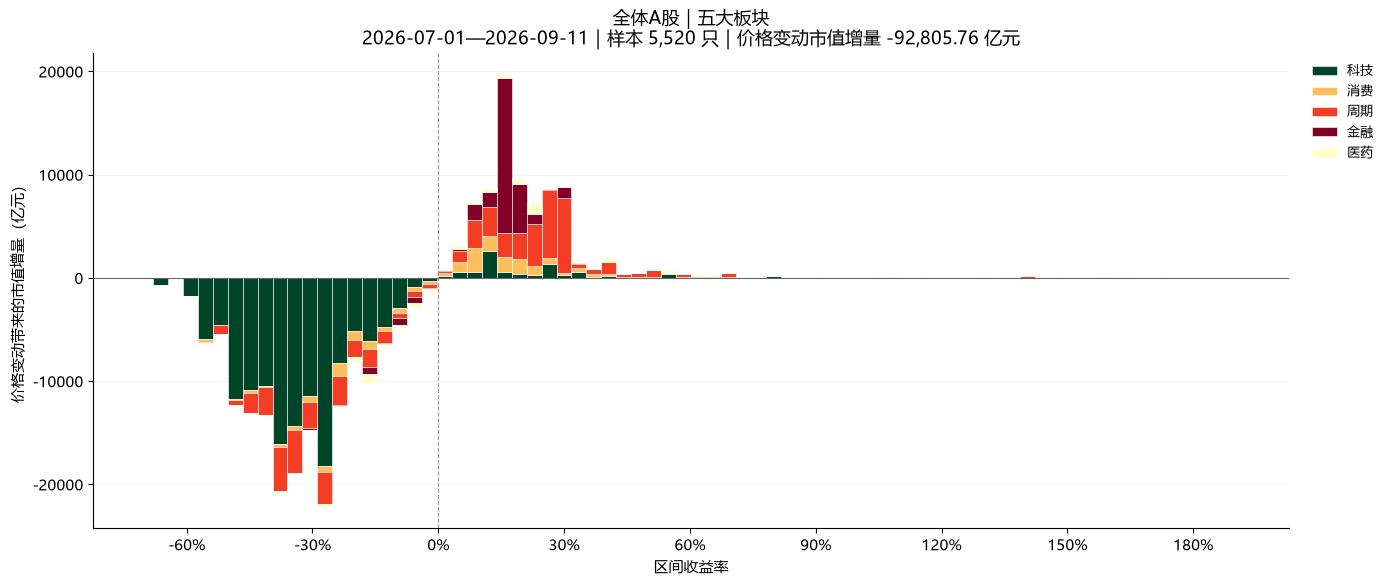

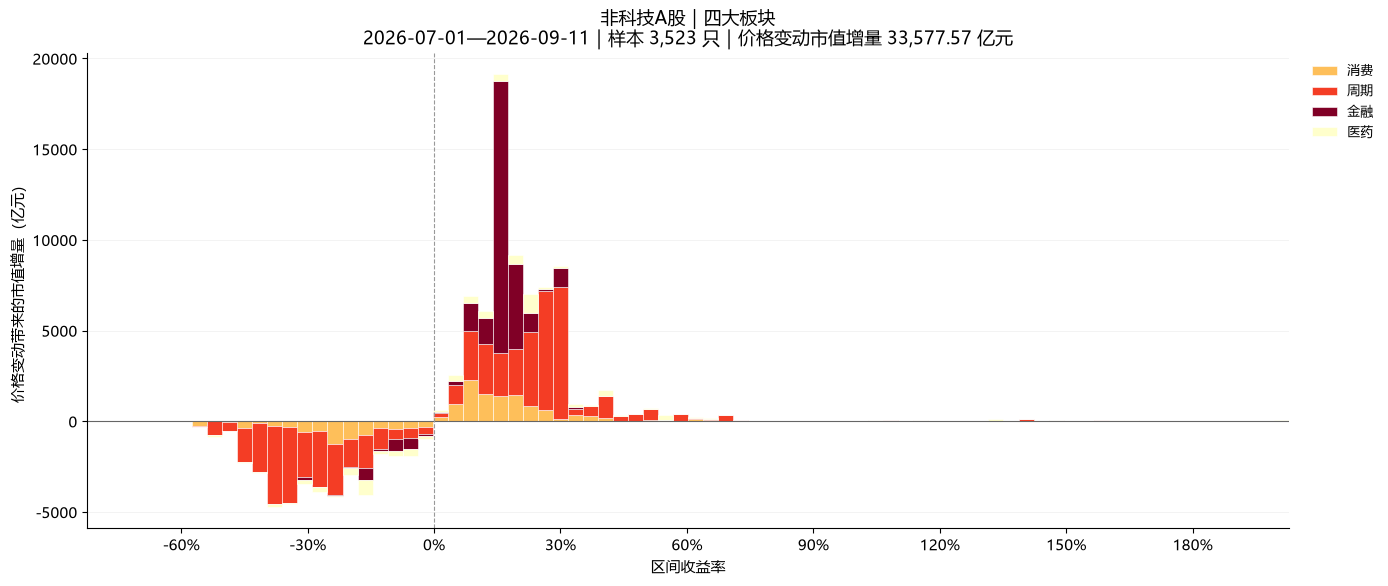

In [13]:
# 统计对象："market_cap_change"=价格变动市值增量；"stock_count"=股票数量。
STAT_OBJECT = "market_cap_change"

# 分箱数分别设置。
N_BINS_ALL = 80
N_BINS_NON_TECH = 80

plot_sample_charts(
    analysis_sample,
    category="big5_l1",
    title="全体A股｜五大板块",
    stat_object=STAT_OBJECT,
    n_bins=N_BINS_ALL,
    positive_cmap="YlOrRd",  # 正值：黄→红

)

plot_sample_charts(
    non_tech_sample,
    category="big5_l1",
    title="非科技A股｜四大板块",
    stat_object=STAT_OBJECT,
    n_bins=N_BINS_NON_TECH,
    positive_cmap="YlOrRd",  # 正值：黄→红

)

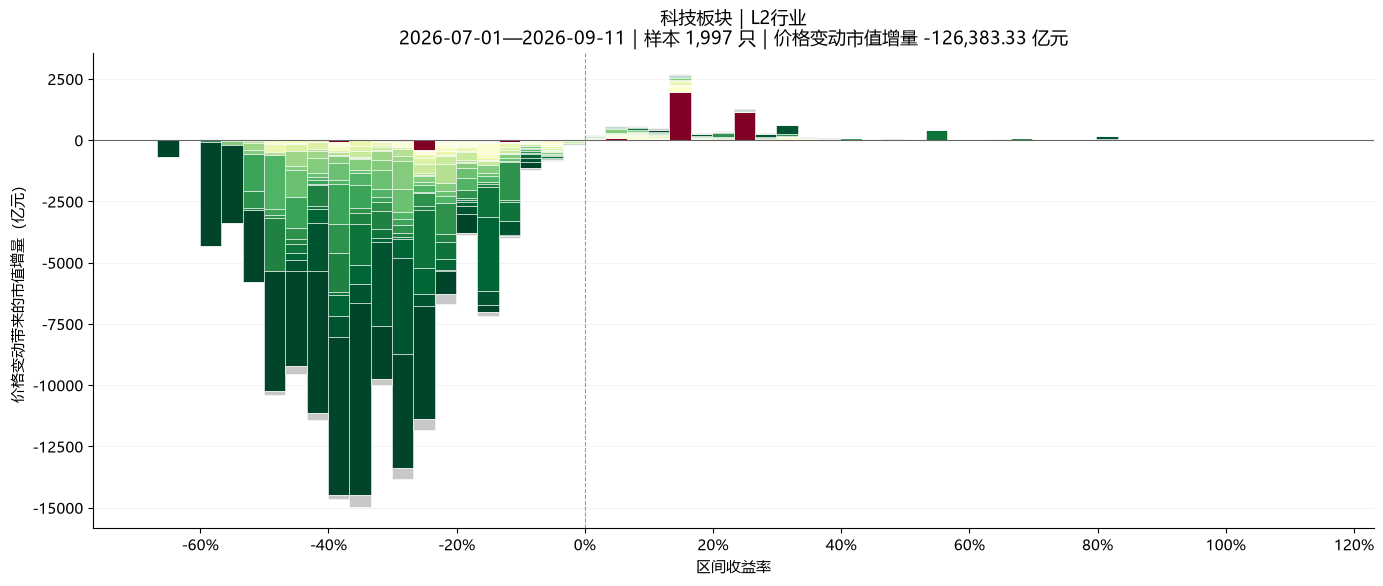

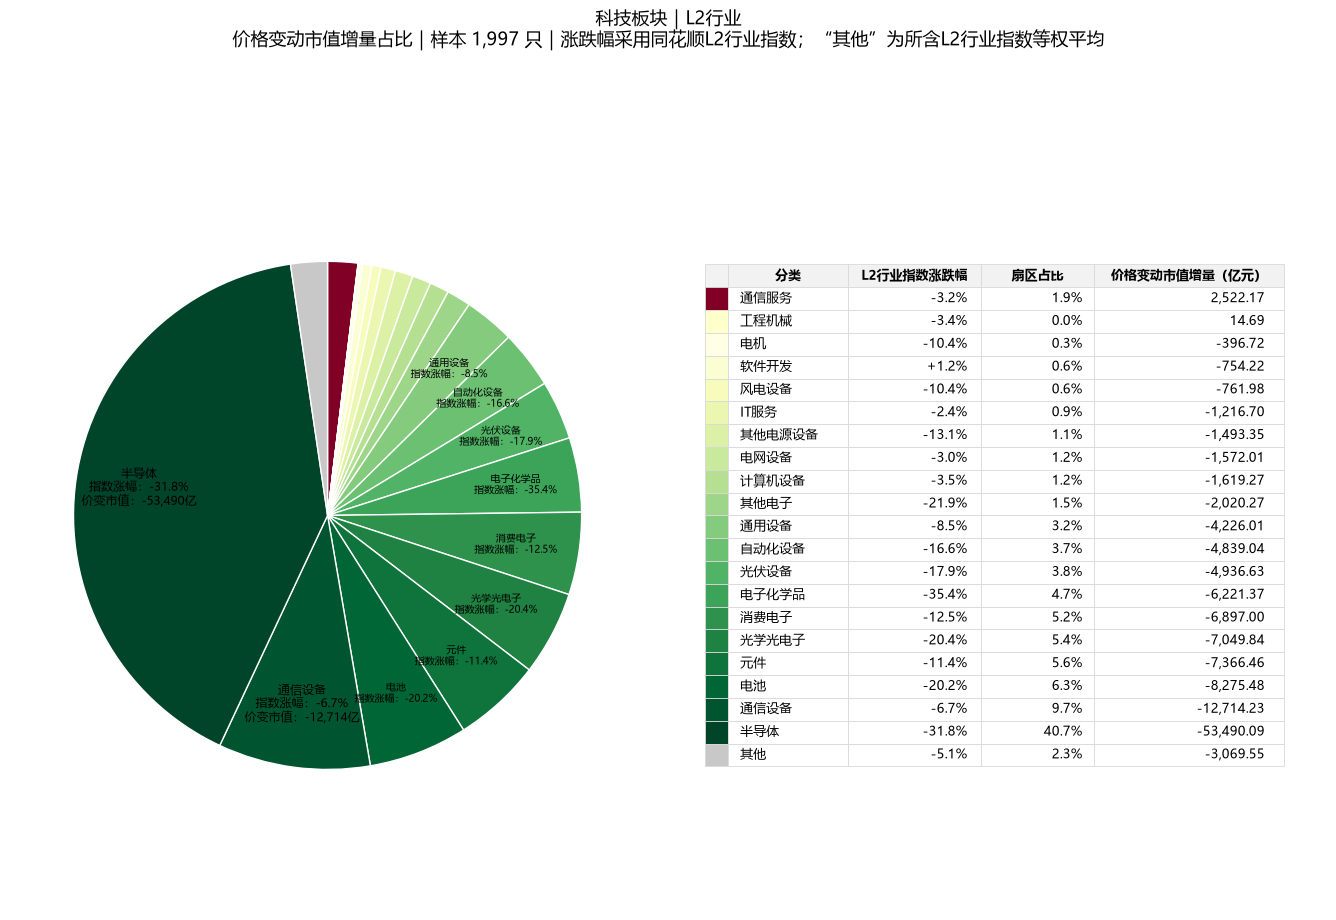

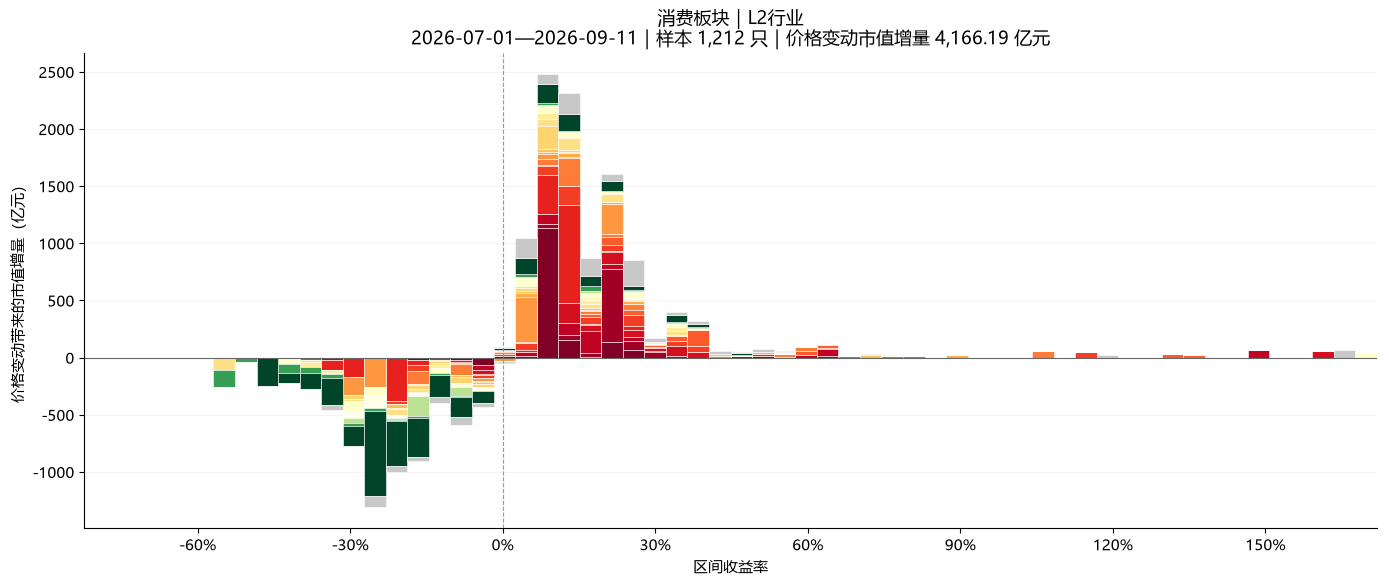

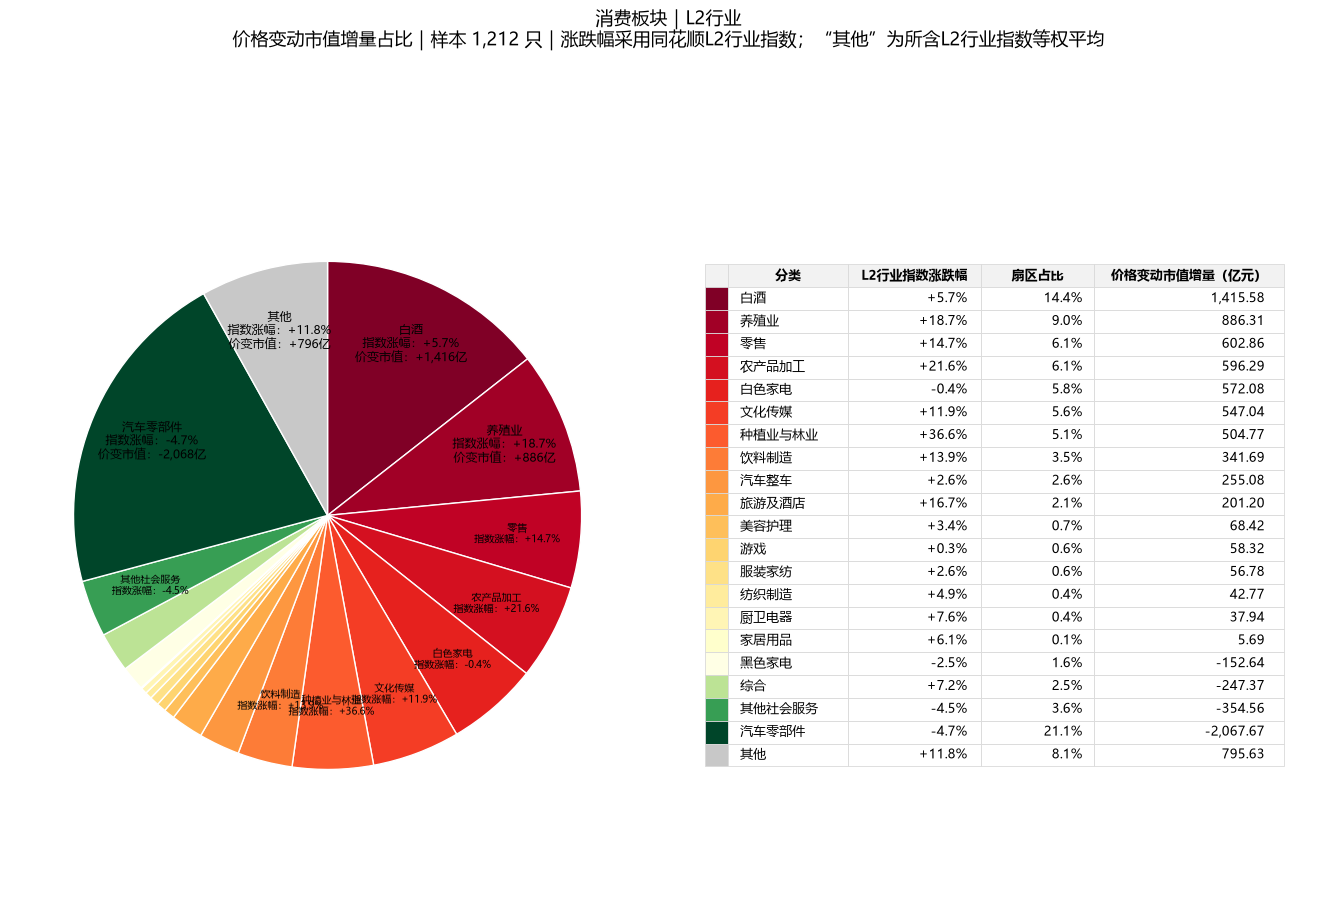

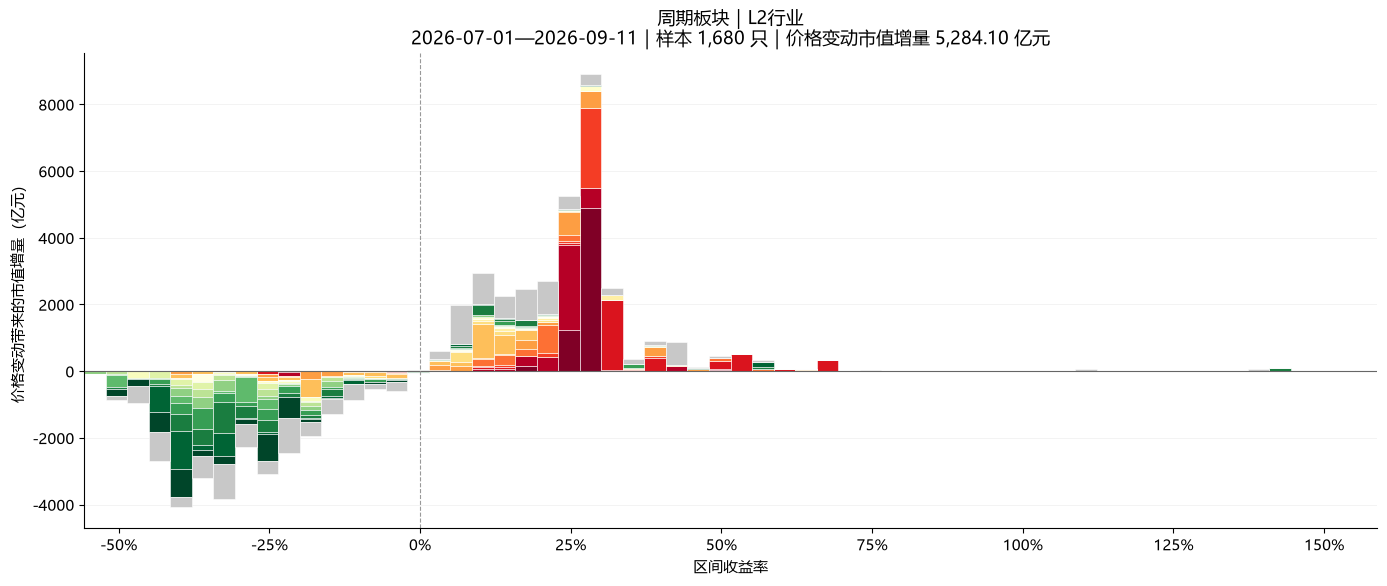

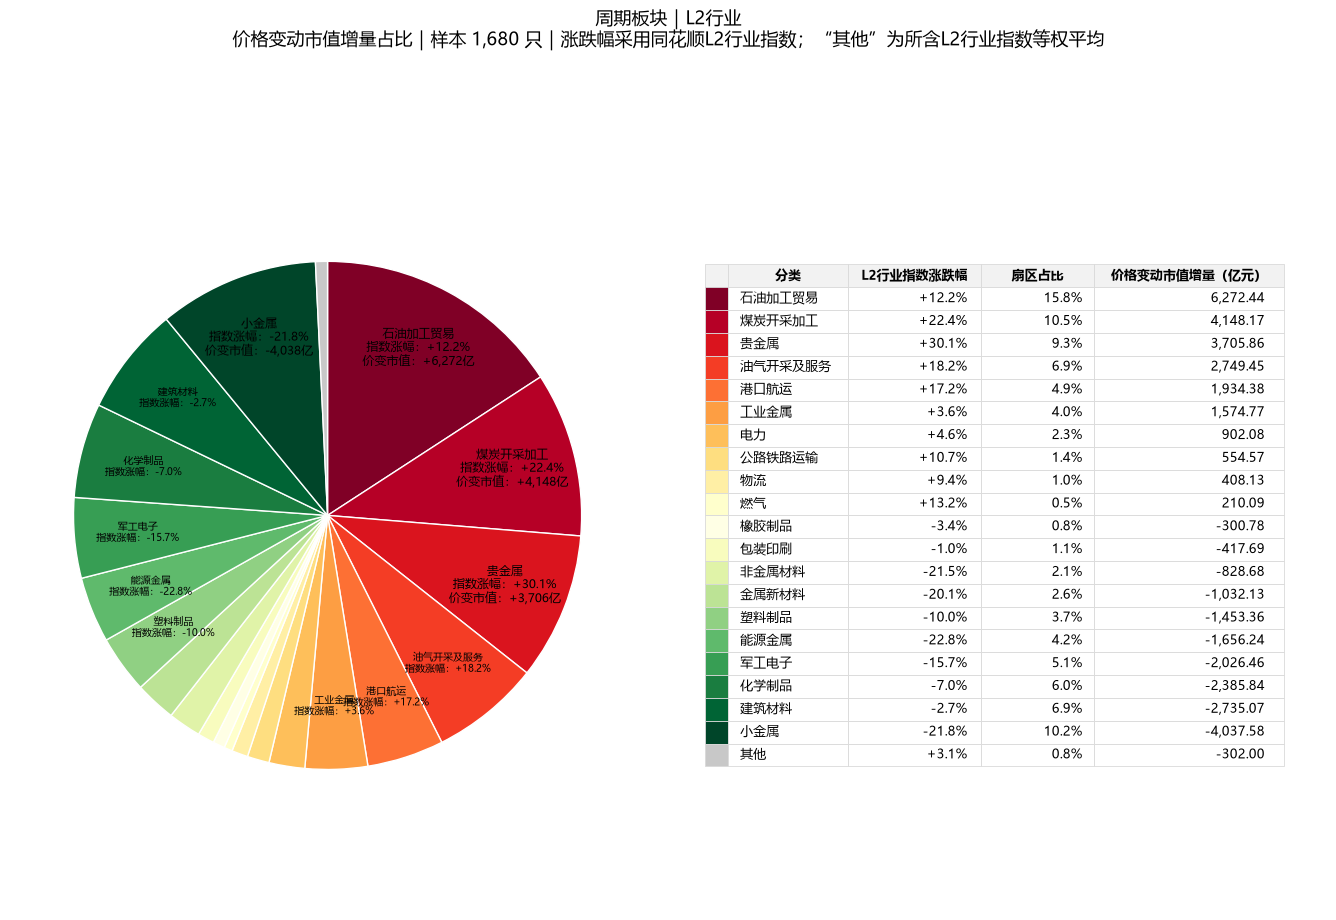

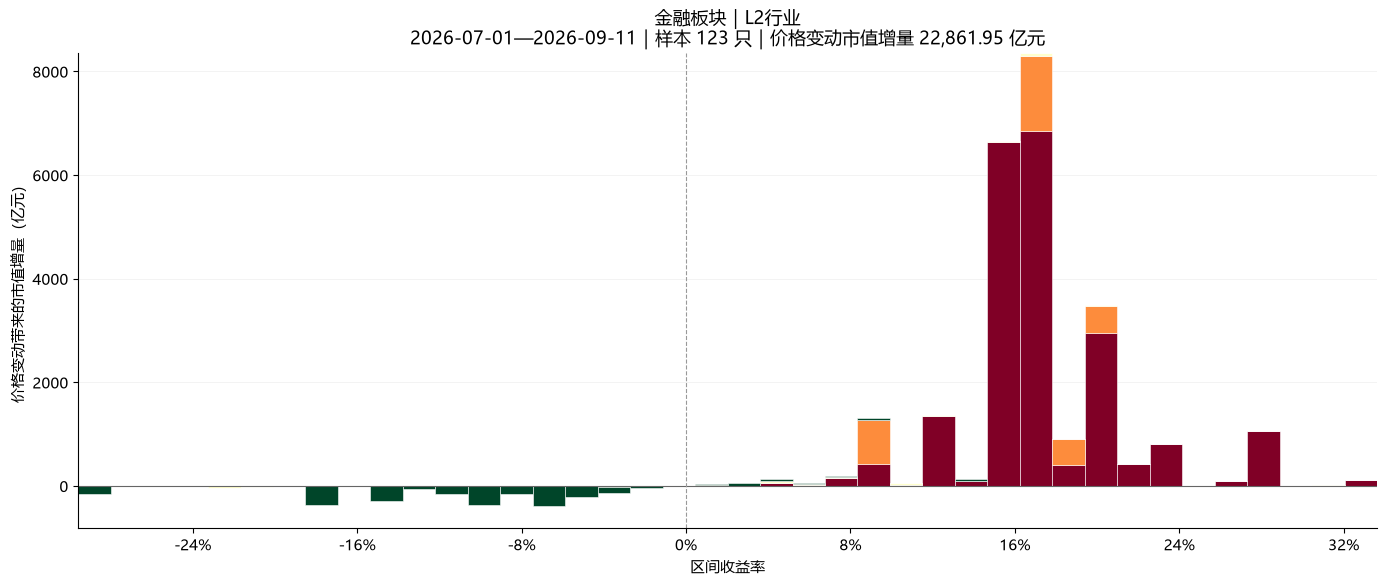

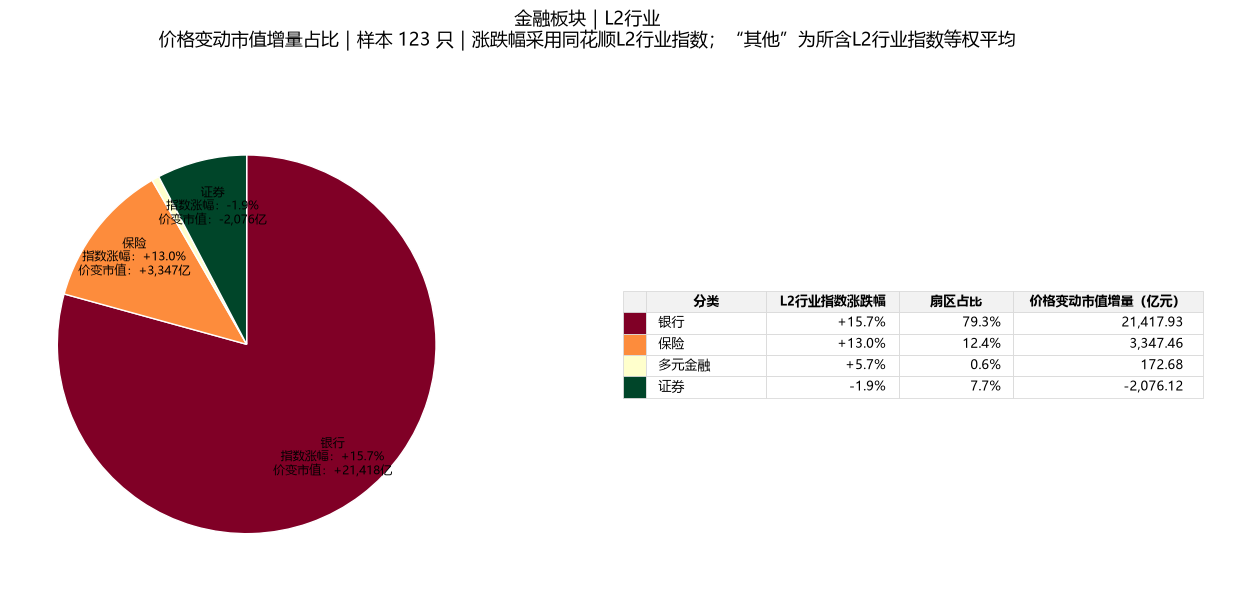

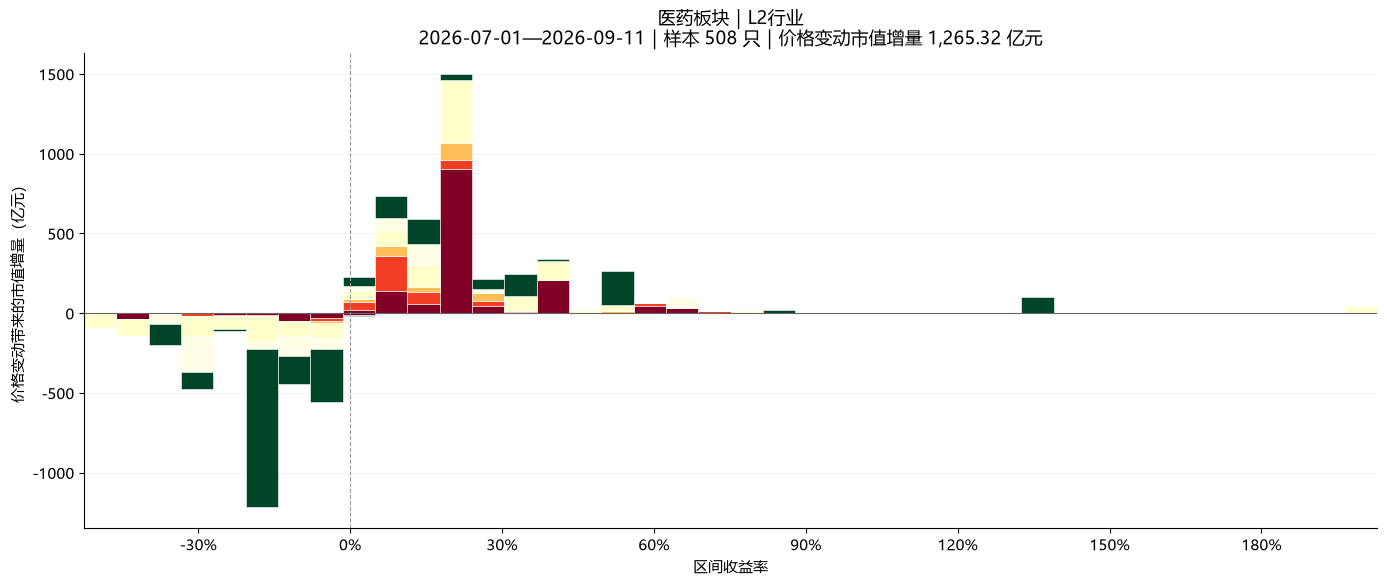

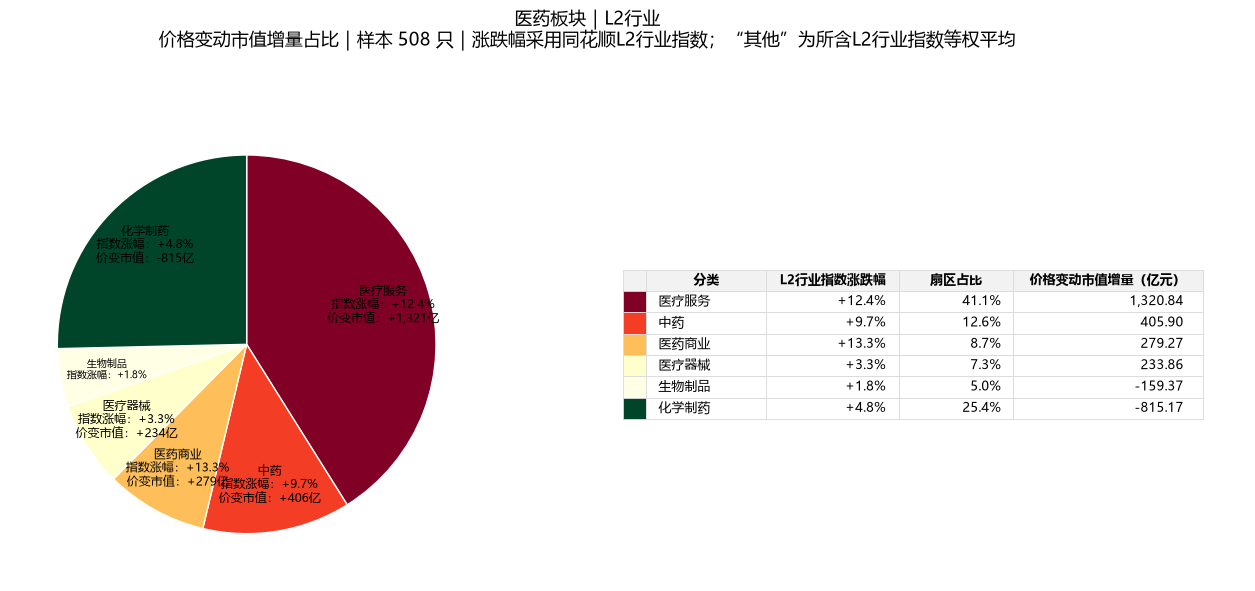

In [14]:
# 统计对象："market_cap_change"=价格变动市值增量；"stock_count"=股票数量。
STAT_OBJECT = "market_cap_change"

# 各板块独立设置；L2显式类别仍按区间价格变动市值增量选取前N和后N。
BOARD_CONFIG = {
    "科技": {
        "n_bins": 60, "top_n": 10, "bottom_n": 10,
        "positive_cmap": "YlOrRd",  # 正值：黄→红
        "negative_cmap": "YlGn",    # 负值：黄→绿
    },
    "消费": {
        "n_bins": 60, "top_n": 10, "bottom_n": 10,
        "positive_cmap": "YlOrRd",  # 正值：黄→红
        "negative_cmap": "YlGn",    # 负值：黄→绿
    },
    "周期": {
        "n_bins": 60, "top_n": 10, "bottom_n": 10,
        "positive_cmap": "YlOrRd",  # 正值：黄→红
        "negative_cmap": "YlGn",    # 负值：黄→绿
    },
    "金融": {
        "n_bins": 40, "top_n": 10, "bottom_n": 10,
        "positive_cmap": "YlOrRd",  # 正值：黄→红
        "negative_cmap": "YlGn",    # 负值：黄→绿
    },
    "医药": {
        "n_bins": 40, "top_n": 10, "bottom_n": 10,
        "positive_cmap": "YlOrRd",  # 正值：黄→红
        "negative_cmap": "YlGn",    # 负值：黄→绿
    },
}


for sector, config in BOARD_CONFIG.items():
    plot_sample_charts(
        analysis_sample.loc[analysis_sample["big5_l1"].eq(sector)],
        category="l2_name",
        title=f"{sector}板块｜L2行业",
        stat_object=STAT_OBJECT,
        show_pie=True,
        **config,
    )

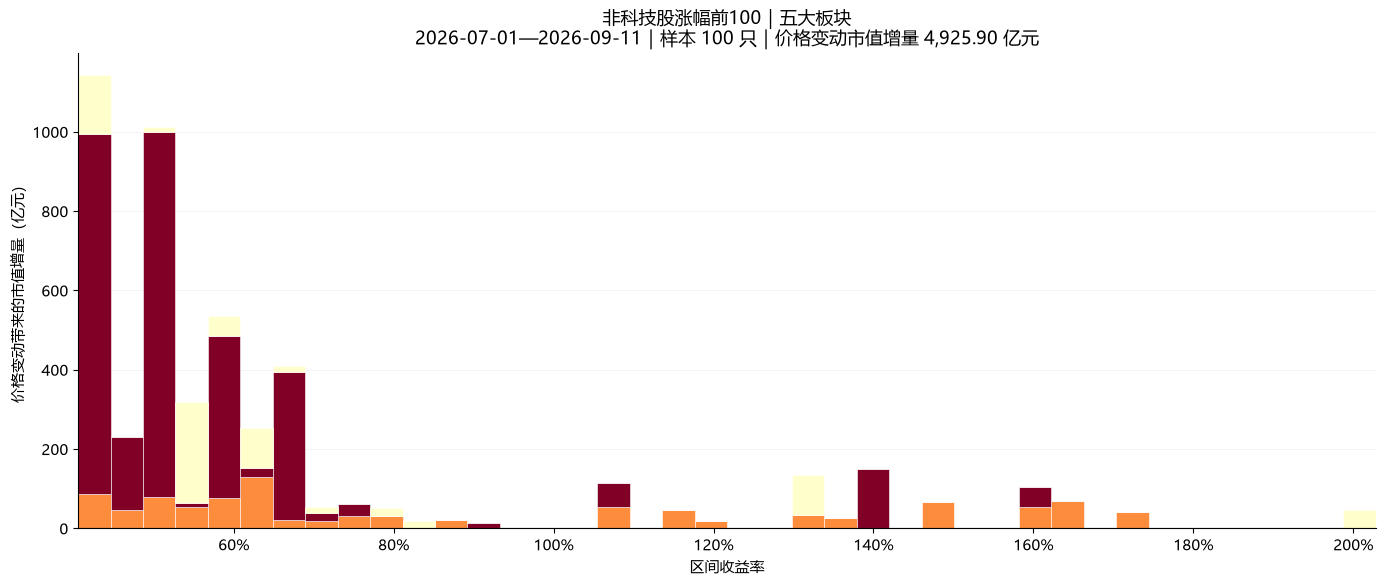

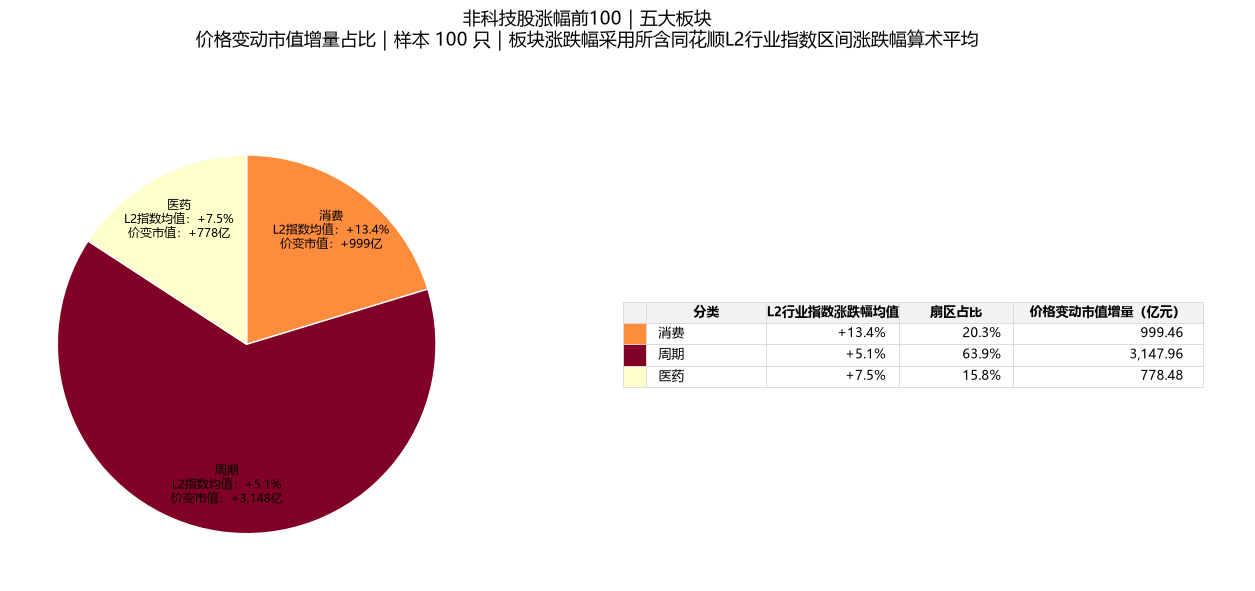

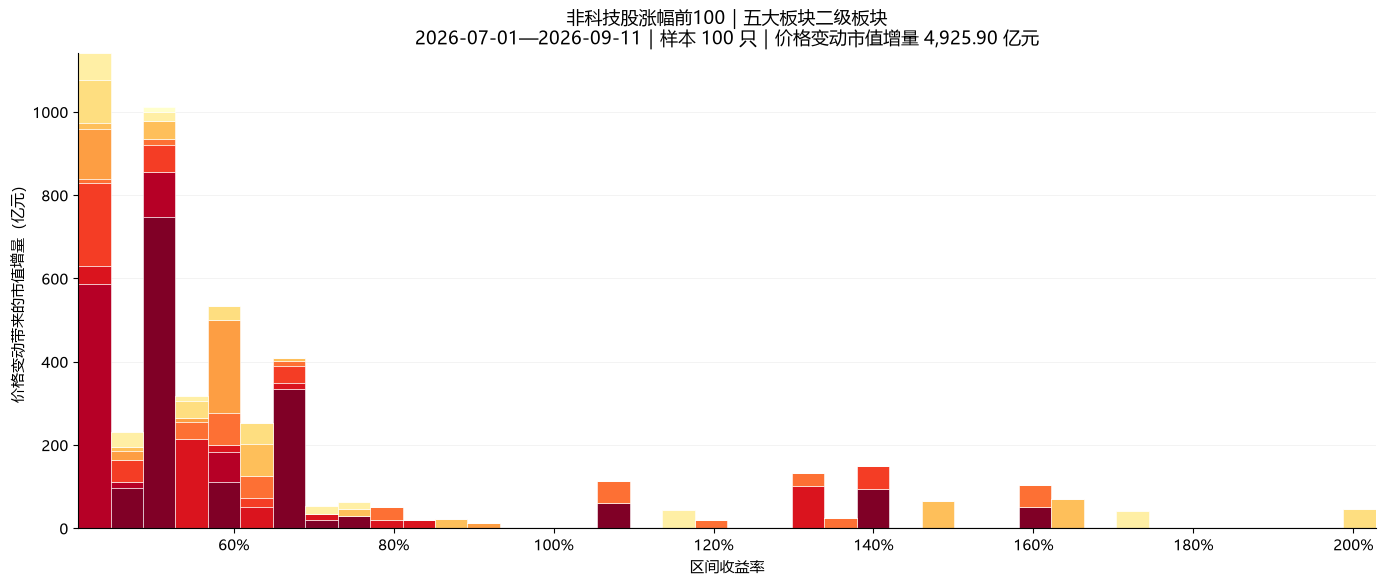

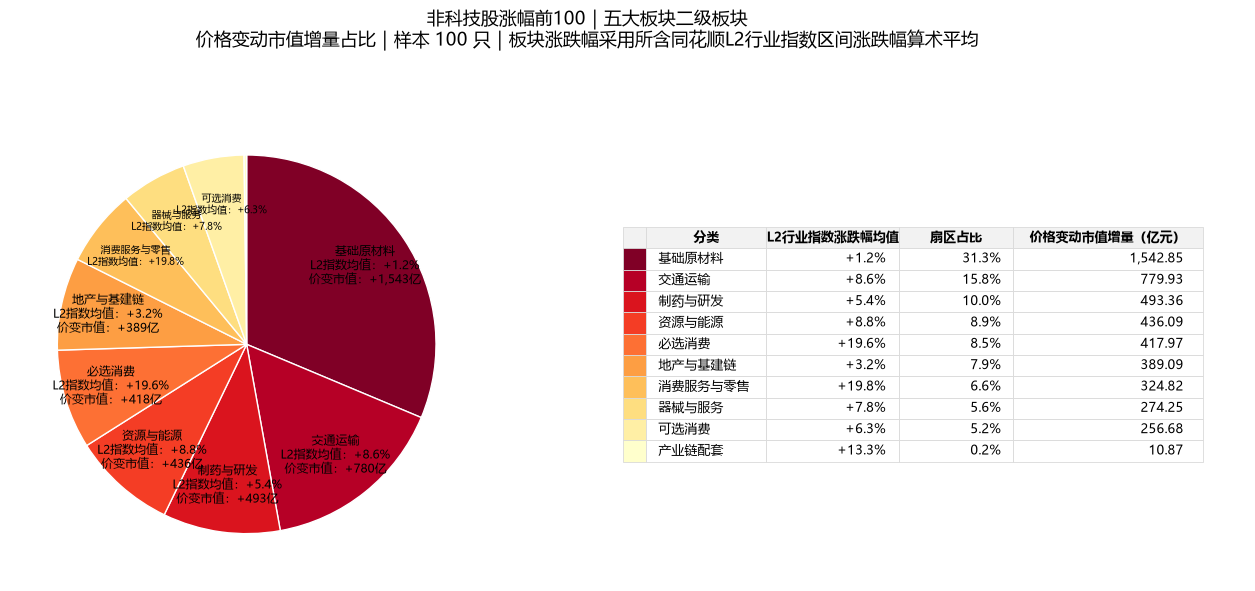

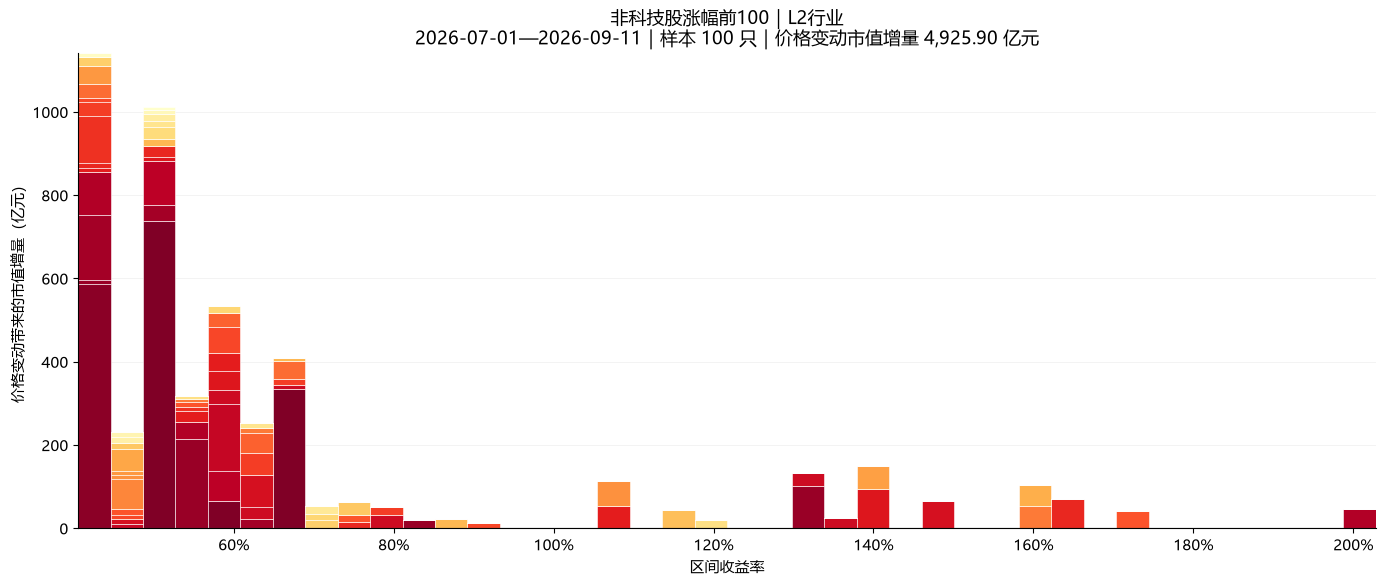

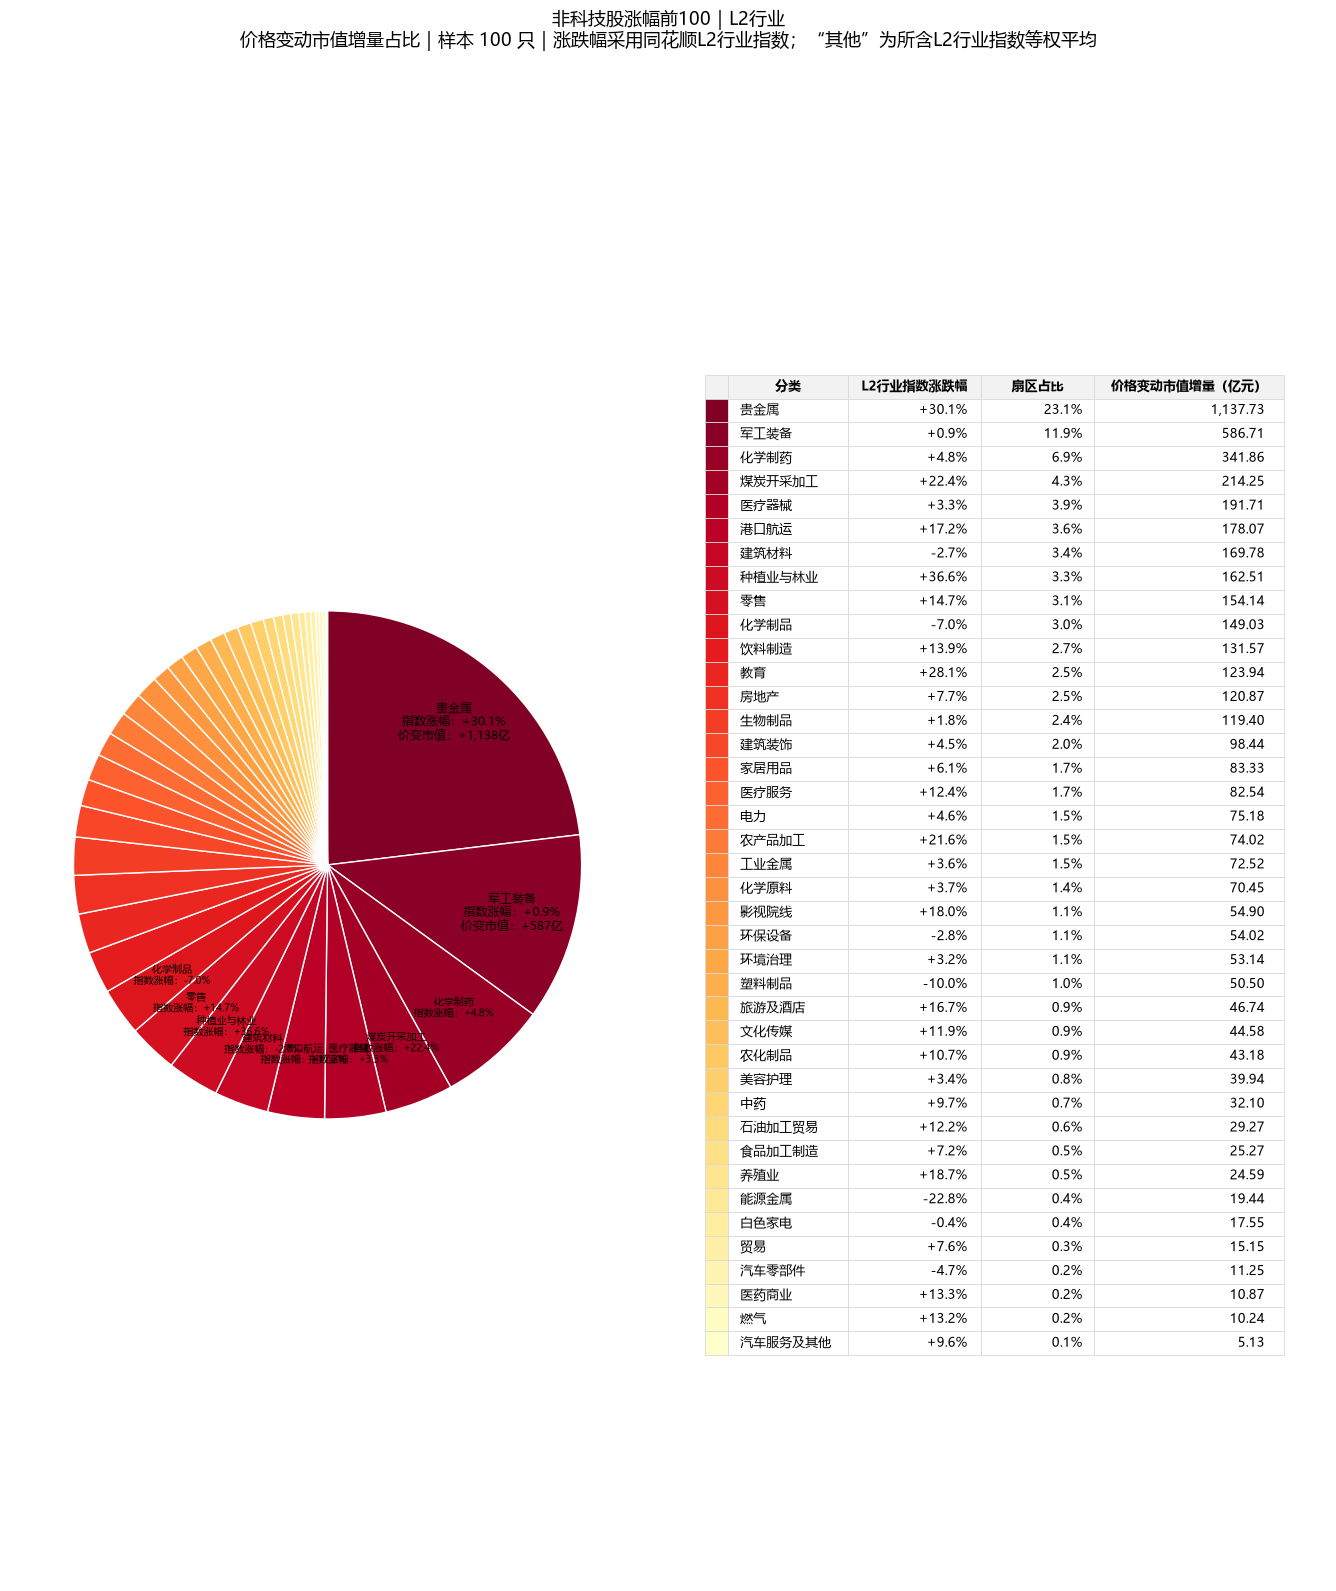

In [15]:
# 统计对象："market_cap_change"=价格变动市值增量；"stock_count"=股票数量。
STAT_OBJECT = "market_cap_change"

# 前100仍按个股区间涨幅选定。
N_BINS_TOP100 = 40

TOP100_L2_TOP_N = 20
TOP100_L2_BOTTOM_N = 20

plot_sample_charts(
    top100_sample,
    category="big5_l1",
    title="非科技股涨幅前100｜五大板块",
    stat_object=STAT_OBJECT,
    n_bins=N_BINS_TOP100,
    show_pie=True,
    positive_cmap="YlOrRd",  # 正值：黄→红
    negative_cmap="YlGn",    # 负值：黄→绿
)

plot_sample_charts(
    top100_sample,
    category="big5_l2",
    title="非科技股涨幅前100｜五大板块二级板块",
    stat_object=STAT_OBJECT,
    n_bins=N_BINS_TOP100,
    show_pie=True,
    positive_cmap="YlOrRd",  # 正值：黄→红
    negative_cmap="YlGn",    # 负值：黄→绿
)

plot_sample_charts(
    top100_sample,
    category="l2_name",
    title="非科技股涨幅前100｜L2行业",
    stat_object=STAT_OBJECT,
    n_bins=N_BINS_TOP100,
    top_n=TOP100_L2_TOP_N,
    bottom_n=TOP100_L2_BOTTOM_N,
    show_pie=True,
    positive_cmap="YlOrRd",  # 正值：黄→红
    negative_cmap="YlGn",    # 负值：黄→绿
)

,big5_l1,l2_name,非科技股数量,前100数量,行业指数区间涨跌幅,非科技股占比,前100占比,入选率,富集倍数
0,消费,种植业与林业,30,7,+36.59%,0.85%,7.00%,23.33%,8.22
1,周期,建筑装饰,143,5,+4.46%,4.06%,5.00%,3.50%,1.23
2,周期,贵金属,14,4,+30.10%,0.40%,4.00%,28.57%,10.07
3,消费,教育,15,4,+28.08%,0.43%,4.00%,26.67%,9.39
4,周期,煤炭开采加工,34,4,+22.42%,0.97%,4.00%,11.76%,4.14
5,消费,饮料制造,46,4,+13.87%,1.31%,4.00%,8.70%,3.06
6,医药,生物制品,54,4,+1.79%,1.53%,4.00%,7.41%,2.61
7,医药,医疗服务,56,4,+12.37%,1.59%,4.00%,7.14%,2.52
8,消费,零售,71,4,+14.67%,2.02%,4.00%,5.63%,1.98
9,消费,家居用品,99,4,+6.11%,2.81%,4.00%,4.04%,1.42


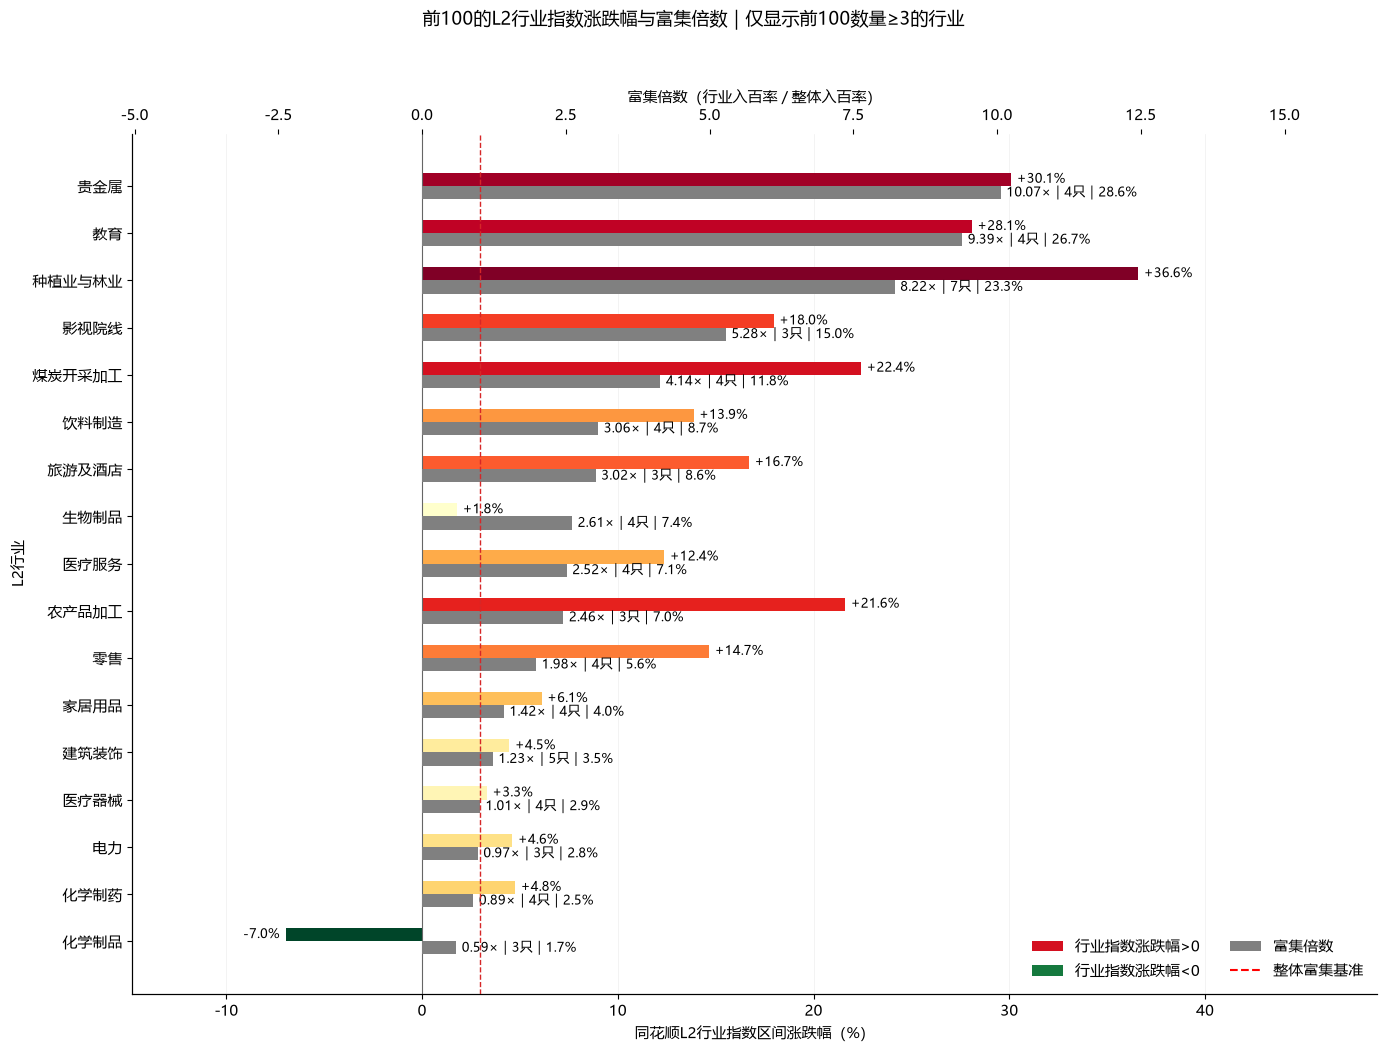

In [16]:
# 1. L2行业富集：既看前100数量，也看相对于行业股票总数的入选率。
overall_selection_rate = len(top100_sample) / len(non_tech_sample)

industry_enrichment = (
    non_tech_sample
    .assign(is_top100=non_tech_sample["code"].isin(top100_codes))
    .groupby(["big5_l1", "l2_name"], observed=True)
    .agg(
        非科技股数量=("code", "size"),
        前100数量=("is_top100", "sum"),
    )
    .reset_index()
    .merge(
        industry_interval_returns[["l2_name", "行业指数区间涨跌幅"]],
        on="l2_name", how="left", validate="one_to_one",
    )
)
assert industry_enrichment["行业指数区间涨跌幅"].notna().all()
industry_enrichment["非科技股占比"] = industry_enrichment["非科技股数量"] / len(non_tech_sample)
industry_enrichment["前100占比"] = industry_enrichment["前100数量"] / len(top100_sample)
industry_enrichment["入选率"] = industry_enrichment["前100数量"] / industry_enrichment["非科技股数量"]
industry_enrichment["富集倍数"] = industry_enrichment["入选率"] / overall_selection_rate
industry_enrichment = industry_enrichment.sort_values(
    ["前100数量", "富集倍数"], ascending=[False, False]
).reset_index(drop=True)

display(
    industry_enrichment.loc[industry_enrichment["前100数量"].gt(0)]
    .style.format({
        "非科技股占比": "{:.2%}",
        "前100占比": "{:.2%}",
        "入选率": "{:.2%}",
        "富集倍数": "{:.2f}",
        "行业指数区间涨跌幅": "{:+.2f}%",
    })
)

MIN_TOP100_PER_L2 = 3  # 图中至少包含多少只前100股票，避免单只股票造成的极端入选率
industry_plot = (
    industry_enrichment.loc[industry_enrichment["前100数量"].ge(MIN_TOP100_PER_L2)]
    .sort_values("富集倍数")
    .copy()
)

# 行业指数涨跌幅颜色：正值、负值分别使用两条色带，组内按数值等间隔取色。
RETURN_POSITIVE_CMAP = "YlOrRd"
RETURN_NEGATIVE_CMAP = "YlGn"
return_values = industry_plot.set_index("l2_name")["行业指数区间涨跌幅"]
return_colors = pd.Series("#999999", index=return_values.index, dtype=object)
positive_order = return_values[return_values.gt(0)].sort_values().index
negative_order = return_values[return_values.lt(0)].sort_values(ascending=False).index
for order, cmap_name in [
    (positive_order, RETURN_POSITIVE_CMAP),
    (negative_order, RETURN_NEGATIVE_CMAP),
]:
    positions = np.linspace(0, 1, len(order)) if len(order) > 1 else np.array([1.0])
    return_colors.loc[order] = list(plt.get_cmap(cmap_name)(positions))

from matplotlib.patches import Patch
from matplotlib.lines import Line2D

y = np.arange(len(industry_plot))
bar_height = 0.28
fig, ax_return = plt.subplots(figsize=(14, max(6, 0.62 * len(industry_plot))))
ax_enrichment = ax_return.twiny()

return_bars = ax_return.barh(
    y + bar_height / 2, industry_plot["行业指数区间涨跌幅"],
    color=return_colors.reindex(industry_plot["l2_name"]).tolist(),
    height=bar_height,
)
enrichment_bars = ax_enrichment.barh(
    y - bar_height / 2, industry_plot["富集倍数"],
    color="gray", height=bar_height,
)

ax_return.set_yticks(y, industry_plot["l2_name"])
ax_return.set_xlabel("同花顺L2行业指数区间涨跌幅（%）")
ax_return.set_ylabel("L2行业")
ax_return.grid(axis="x", alpha=0.2)
ax_return.set_axisbelow(True)
ax_enrichment.set_xlabel("富集倍数（行业入百率 / 整体入百率）")

# 双X轴使用不同单位，但把两者的0对齐到同一条纵线。
return_span = max(
    industry_plot["行业指数区间涨跌幅"].max() - industry_plot["行业指数区间涨跌幅"].min(),
    1,
)
return_left = min(0, industry_plot["行业指数区间涨跌幅"].min()) - return_span * 0.18
return_right = max(0, industry_plot["行业指数区间涨跌幅"].max()) + return_span * 0.28
ax_return.set_xlim(return_left, return_right)
zero_position = (0 - return_left) / (return_right - return_left)
enrichment_right = industry_plot["富集倍数"].max() * 1.65
enrichment_left = -zero_position / (1 - zero_position) * enrichment_right
ax_enrichment.set_xlim(enrichment_left, enrichment_right)
ax_return.axvline(0, color="#666666", linewidth=0.8, zorder=5)
ax_enrichment.axvline(
    1, color="#D62728", linestyle="--", linewidth=1, zorder=4,
)

for bar, value in zip(return_bars, industry_plot["行业指数区间涨跌幅"]):
    ax_return.annotate(
        f"{value:+.1f}%",
        xy=(value, bar.get_y() + bar.get_height() / 2),
        xytext=(4 if value >= 0 else -4, 0),
        textcoords="offset points",
        va="center",
        ha="left" if value >= 0 else "right",
        fontsize=9,
    )
for bar, (_, row) in zip(enrichment_bars, industry_plot.iterrows()):
    ax_enrichment.annotate(
        f"{row['富集倍数']:.2f}×｜{int(row['前100数量'])}只｜{row['入选率']:.1%}",
        xy=(row["富集倍数"], bar.get_y() + bar.get_height() / 2),
        xytext=(4, 0),
        textcoords="offset points",
        va="center", ha="left", fontsize=9,
    )

ax_return.legend(
    handles=[
        Patch(facecolor=plt.get_cmap(RETURN_POSITIVE_CMAP)(0.8), label="行业指数涨跌幅>0"),
        Patch(facecolor=plt.get_cmap(RETURN_NEGATIVE_CMAP)(0.8), label="行业指数涨跌幅<0"),
        Patch(facecolor="gray", label="富集倍数"),
        Line2D([0], [0], color="red", linestyle="--", label="整体富集基准"),
    ],
    frameon=False, loc="lower right", ncol=2,
)

fig.suptitle(
    f"前100的L2行业指数涨跌幅与富集倍数｜仅显示前100数量≥{MIN_TOP100_PER_L2}的行业",
    y=0.995,
)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## 因子篇章

本篇复用统一预处理的个股大表和共同前100名单；财务披露事件及其 `merge_asof` 只在本篇内部生成。


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter, MaxNLocator

# 因子统一设置：财务信息在披露日后的下一交易日生效；收益预测期为未来5个交易日。
FACTOR_WINDOW = 20
FORWARD_DAYS = 5
FACTOR_ORDER = ["value", "profitability", "leverage", "investment",
                "size", "momentum", "volatility", "liquidity"]
FACTOR_META = {
    "value": {"label": "价值", "xlabel": "账面市值比 B/P", "scale": 1},
    "profitability": {"label": "盈利", "xlabel": "年化ROE（%）", "scale": 100},
    "leverage": {"label": "杠杆", "xlabel": "资产负债率（%）", "scale": 100},
    "investment": {"label": "投资", "xlabel": "总资产环比增长率（%）", "scale": 100},
    "size": {"label": "规模", "xlabel": "ln（总市值/元）", "scale": 1},
    "momentum": {"label": "动量", "xlabel": "过去20日收益率（%）", "scale": 100},
    "volatility": {"label": "波动", "xlabel": "20日年化波动率（%）", "scale": 100},
    "liquidity": {"label": "流动性", "xlabel": "20日平均成交额/总市值（%）", "scale": 100},
}

def normalize_financial_code(symbols):
    return (symbols.astype(str)
            .str.replace(r"\.SH$", ".XSHG", regex=True)
            .str.replace(r"\.SZ$", ".XSHE", regex=True)
            .str.replace(r"\.BJ$", ".XBSE", regex=True))

factor_trade_days = pd.DatetimeIndex(sorted(daily_data["time"].unique()))

def next_trade_day_after(date_series):
    dates = pd.to_datetime(date_series)
    positions = factor_trade_days.searchsorted(dates.to_numpy(), side="right")
    result = pd.Series(pd.NaT, index=dates.index, dtype="datetime64[ns]")
    valid = positions < len(factor_trade_days)
    result.loc[valid] = factor_trade_days.take(positions[valid]).to_numpy()
    return result

def prepare_financial_event(period, previous_period):
    current_balance = balance[period][[
        "balance_stat_symbol", "balance_stat_report_date",
        "balance_stat_total_assets", "balance_stat_total_liabilities",
        "balance_stat_total_quity_atsopc",
    ]].rename(columns={
        "balance_stat_symbol": "symbol",
        "balance_stat_report_date": "balance_report_date",
        "balance_stat_total_assets": "total_assets",
        "balance_stat_total_liabilities": "total_liabilities",
        "balance_stat_total_quity_atsopc": "book_equity",
    })
    current_income = income_sq[period][[
        "income_sq_stat_symbol", "income_sq_stat_report_date",
        "income_sq_stat_np_atsopc",
    ]].rename(columns={
        "income_sq_stat_symbol": "symbol",
        "income_sq_stat_report_date": "income_report_date",
        "income_sq_stat_np_atsopc": "net_profit_parent",
    })
    previous_balance = balance[previous_period][[
        "balance_stat_symbol", "balance_stat_total_assets",
        "balance_stat_total_quity_atsopc",
    ]].rename(columns={
        "balance_stat_symbol": "symbol",
        "balance_stat_total_assets": "previous_assets",
        "balance_stat_total_quity_atsopc": "previous_equity",
    })
    event = (current_balance
             .merge(current_income, on="symbol", how="inner", validate="one_to_one")
             .merge(previous_balance, on="symbol", how="left", validate="one_to_one"))
    event["code"] = normalize_financial_code(event["symbol"])
    event["report_period"] = period
    event["report_date"] = event[["balance_report_date", "income_report_date"]].apply(
        pd.to_datetime
    ).max(axis=1)
    event["effective_date"] = next_trade_day_after(event["report_date"])
    average_equity = (event["book_equity"] + event["previous_equity"]) / 2
    event["profitability"] = 4 * event["net_profit_parent"] / average_equity
    event["leverage"] = event["total_liabilities"] / event["total_assets"]
    event["investment"] = event["total_assets"] / event["previous_assets"] - 1
    return event[["code", "report_period", "report_date", "effective_date",
                  "book_equity", "profitability", "leverage", "investment"]]

financial_events = pd.concat([
    prepare_financial_event("2026q1", "2025q4"),
    prepare_financial_event("2026q2", "2026q1"),
], ignore_index=True).dropna(subset=["effective_date"])
display(financial_events.groupby("report_period").agg(
    股票数=("code", "nunique"), 披露日起点=("report_date", "min"), 披露日终点=("report_date", "max")
))

,股票数,披露日起点,披露日终点
report_period,,,
2026q1,5570,2026-04-08,2026-08-28
2026q2,5565,2026-07-16,2026-09-02


In [18]:
# 构造每日因子面板。财务因子按披露事件阶梯式更新，行情因子每日滚动更新。
factor_source = daily_data.loc[
    daily_data["big5_l1"].isin(NON_TECH_SECTORS),
    ["time", "code", "l2_name", "big5_l1", "close", "daily_return",
     "money", "market_cap"],
].copy()
factor_source = factor_source.sort_values(["time", "code"])
financial_events_for_merge = financial_events.sort_values(["effective_date", "code"])

factor_panel = pd.merge_asof(
    factor_source,
    financial_events_for_merge,
    left_on="time", right_on="effective_date", by="code",
    direction="backward", allow_exact_matches=True,
).sort_values(["code", "time"]).reset_index(drop=True)

factor_panel["value"] = factor_panel["book_equity"] / factor_panel["market_cap"]
factor_panel["size"] = np.log(factor_panel["market_cap"])
factor_panel["momentum"] = (
    factor_panel["close"] / factor_panel.groupby("code")["close"].shift(FACTOR_WINDOW) - 1
)
factor_panel["volatility"] = (
    factor_panel.groupby("code")["daily_return"]
    .transform(lambda x: x.rolling(FACTOR_WINDOW, min_periods=FACTOR_WINDOW).std(ddof=0))
    * np.sqrt(252)
)
factor_panel["turnover_proxy"] = factor_panel["money"] / factor_panel["market_cap"]
factor_panel["liquidity"] = (
    factor_panel.groupby("code")["turnover_proxy"]
    .transform(lambda x: x.rolling(FACTOR_WINDOW, min_periods=FACTOR_WINDOW).mean())
)
factor_panel["forward_return"] = (
    factor_panel.groupby("code")["close"].shift(-FORWARD_DAYS) / factor_panel["close"] - 1
)
factor_panel = factor_panel.replace([np.inf, -np.inf], np.nan)
factor_panel["forward_return_l2_excess"] = (
    factor_panel["forward_return"]
    - factor_panel.groupby(["time", "l2_name"], observed=True)["forward_return"].transform("mean")
)
factor_panel["is_top100"] = factor_panel["code"].isin(top100_codes)

factor_analysis_panel = factor_panel.loc[
    factor_panel["time"].between(RESEARCH_START_DATE, END_DATE)
    & factor_panel["forward_return"].notna()
].copy()

factor_coverage = pd.DataFrame({
    "有效股票日": factor_analysis_panel[FACTOR_ORDER].notna().sum(),
    "覆盖率": factor_analysis_panel[FACTOR_ORDER].notna().mean(),
})
display(factor_coverage.style.format({"覆盖率": "{:.2%}"}))
print(
    f"因子分析日期：{factor_analysis_panel['time'].min():%Y-%m-%d}—"
    f"{factor_analysis_panel['time'].max():%Y-%m-%d}；未来收益期：{FORWARD_DAYS}个交易日"
)

,有效股票日,覆盖率
value,169426,99.96%
profitability,169365,99.92%
leverage,169426,99.96%
investment,169426,99.96%
size,169501,100.00%
momentum,169178,99.81%
volatility,169178,99.81%
liquidity,169192,99.82%


因子分析日期：2026-07-01—2026-09-04；未来收益期：5个交易日


In [19]:
# 每日先在L2行业内部按因子分成十分组，再汇总未来5日行业超额收益与Rank IC。
factor_group_stats = {}
factor_daily_ic = {}
factor_distribution_values = {}
factor_summary_rows = []

for factor_name in FACTOR_ORDER:
    columns = ["time", "code", "l2_name", factor_name, "forward_return_l2_excess"]
    data = factor_analysis_panel[columns].dropna().copy()
    data["factor_percentile"] = (
        data.groupby(["time", "l2_name"], observed=True)[factor_name]
        .rank(method="first", pct=True)
    )
    data["factor_group"] = np.ceil(data["factor_percentile"] * 10).clip(1, 10).astype(int)

    daily_group_return = (
        data.groupby(["time", "factor_group"], observed=True)["forward_return_l2_excess"]
        .mean().rename("group_return").reset_index()
    )
    stats = daily_group_return.groupby("factor_group")["group_return"].agg(
        mean="mean", median="median",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        dates="size",
    ).reindex(range(1, 11))
    factor_group_stats[factor_name] = stats

    daily_ic = pd.Series({
        date: part["factor_percentile"].corr(
            part["forward_return_l2_excess"], method="spearman"
        )
        for date, part in data.groupby("time", observed=True)
    }).sort_index()
    factor_daily_ic[factor_name] = daily_ic
    factor_distribution_values[factor_name] = data[factor_name]

    valid_means = stats["mean"].dropna()
    group_rho = pd.Series(valid_means.index, index=valid_means.index).corr(
        valid_means, method="spearman"
    )
    differences = valid_means.diff().dropna()
    if differences.gt(0).all():
        monotonicity = "正向单调"
    elif differences.lt(0).all():
        monotonicity = "负向单调"
    else:
        monotonicity = "非单调"

    factor_summary_rows.append({
        "因子": FACTOR_META[factor_name]["label"],
        "分组单调相关ρ": group_rho,
        "平均Rank_IC": daily_ic.mean(),
        "IC标准差": daily_ic.std(ddof=1),
        "ICIR": daily_ic.mean() / daily_ic.std(ddof=1),
        "IC为正比例": daily_ic.gt(0).mean(),
        "单调性": monotonicity,
    })

factor_summary = pd.DataFrame(factor_summary_rows).set_index("因子")
display(factor_summary.style.format({
    "分组单调相关ρ": "{:+.2f}",
    "平均Rank_IC": "{:+.3f}",
    "IC标准差": "{:.3f}",
    "ICIR": "{:+.2f}",
    "IC为正比例": "{:.1%}",
}))

,分组单调相关ρ,平均Rank_IC,IC标准差,ICIR,IC为正比例,单调性
因子,,,,,,
价值,+0.99,+0.083,0.192,+0.43,70.8%,非单调
盈利,-0.96,-0.050,0.102,-0.50,22.9%,非单调
杠杆,+0.59,+0.012,0.038,+0.31,64.6%,非单调
投资,-0.92,-0.033,0.047,-0.70,18.8%,非单调
规模,-0.99,-0.116,0.163,-0.71,20.8%,非单调
动量,-0.95,-0.120,0.174,-0.69,22.9%,非单调
波动,-0.76,-0.098,0.292,-0.34,33.3%,非单调
流动性,-0.93,-0.065,0.278,-0.23,35.4%,非单调


In [20]:
# 参考图样式：上层为十分组未来收益，下层为因子原始分布。
def plot_factor_page(factor_names, page_title):
    fig = plt.figure(figsize=(18, 8.5))
    grid = fig.add_gridspec(
        2, len(factor_names), height_ratios=[1.05, 0.75],
        hspace=0.10, wspace=0.28, left=0.055, right=0.985, top=0.89, bottom=0.08,
    )

    for column, factor_name in enumerate(factor_names):
        meta = FACTOR_META[factor_name]
        stats = factor_group_stats[factor_name]
        summary = factor_summary.loc[meta["label"]]
        x = np.arange(1, 11)

        top_ax = fig.add_subplot(grid[0, column])
        top_ax.fill_between(
            x, stats["q25"], stats["q75"], step="mid",
            color="#DCE9F5", alpha=0.85, label="每日组收益25%—75%",
        )
        top_ax.plot(x, stats["mean"], color="#222222", marker="o",
                    linewidth=1.5, markersize=4, label="均值")
        top_ax.plot(x, stats["median"], color="#3478C5", marker="o",
                    linestyle="--", linewidth=1.2, markersize=3, label="中位数")
        top_ax.axhline(0, color="#888888", linestyle="--", linewidth=0.8)
        top_ax.set_xticks(x, [f"G{i}" for i in x])
        top_ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
        top_ax.grid(alpha=0.18)
        top_ax.set_title(
            f"{meta['label']}｜ρ={summary['分组单调相关ρ']:+.2f}"
            f"｜IC={summary['平均Rank_IC']:+.3f}｜{summary['单调性']}",
            fontsize=11,
        )
        if column == 0:
            top_ax.set_ylabel(f"未来{FORWARD_DAYS}日L2行业超额收益")
            top_ax.legend(loc="best", fontsize=7, frameon=False)
        else:
            top_ax.set_ylabel("")

        bottom_ax = fig.add_subplot(grid[1, column])
        values = factor_distribution_values[factor_name].dropna() * meta["scale"]
        lower, upper = values.quantile([0.01, 0.99])
        values = values.clip(lower, upper)
        q20, q80 = values.quantile([0.20, 0.80])
        counts, edges = np.histogram(values, bins=24, density=False)
        centers = (edges[:-1] + edges[1:]) / 2
        bar_colors = np.where(
            centers <= q20, "#4C78A8",
            np.where(centers >= q80, "#E45756", "#D8D8D8"),
        )
        bottom_ax.bar(
            edges[:-1], counts, width=np.diff(edges), align="edge",
            color=bar_colors, edgecolor="white", linewidth=0.35,
        )
        bottom_ax.set_xlabel(meta["xlabel"])
        bottom_ax.grid(axis="y", alpha=0.18)
        if column == 0:
            bottom_ax.set_ylabel("股票日频数")
        else:
            bottom_ax.set_ylabel("")

    fig.suptitle(
        f"{page_title}\n每日L2行业内十分组｜未来{FORWARD_DAYS}日行业超额收益｜"
        f"下层为股票日频数｜按1%—99%缩尾",
        fontsize=15,
    )
    plt.show()

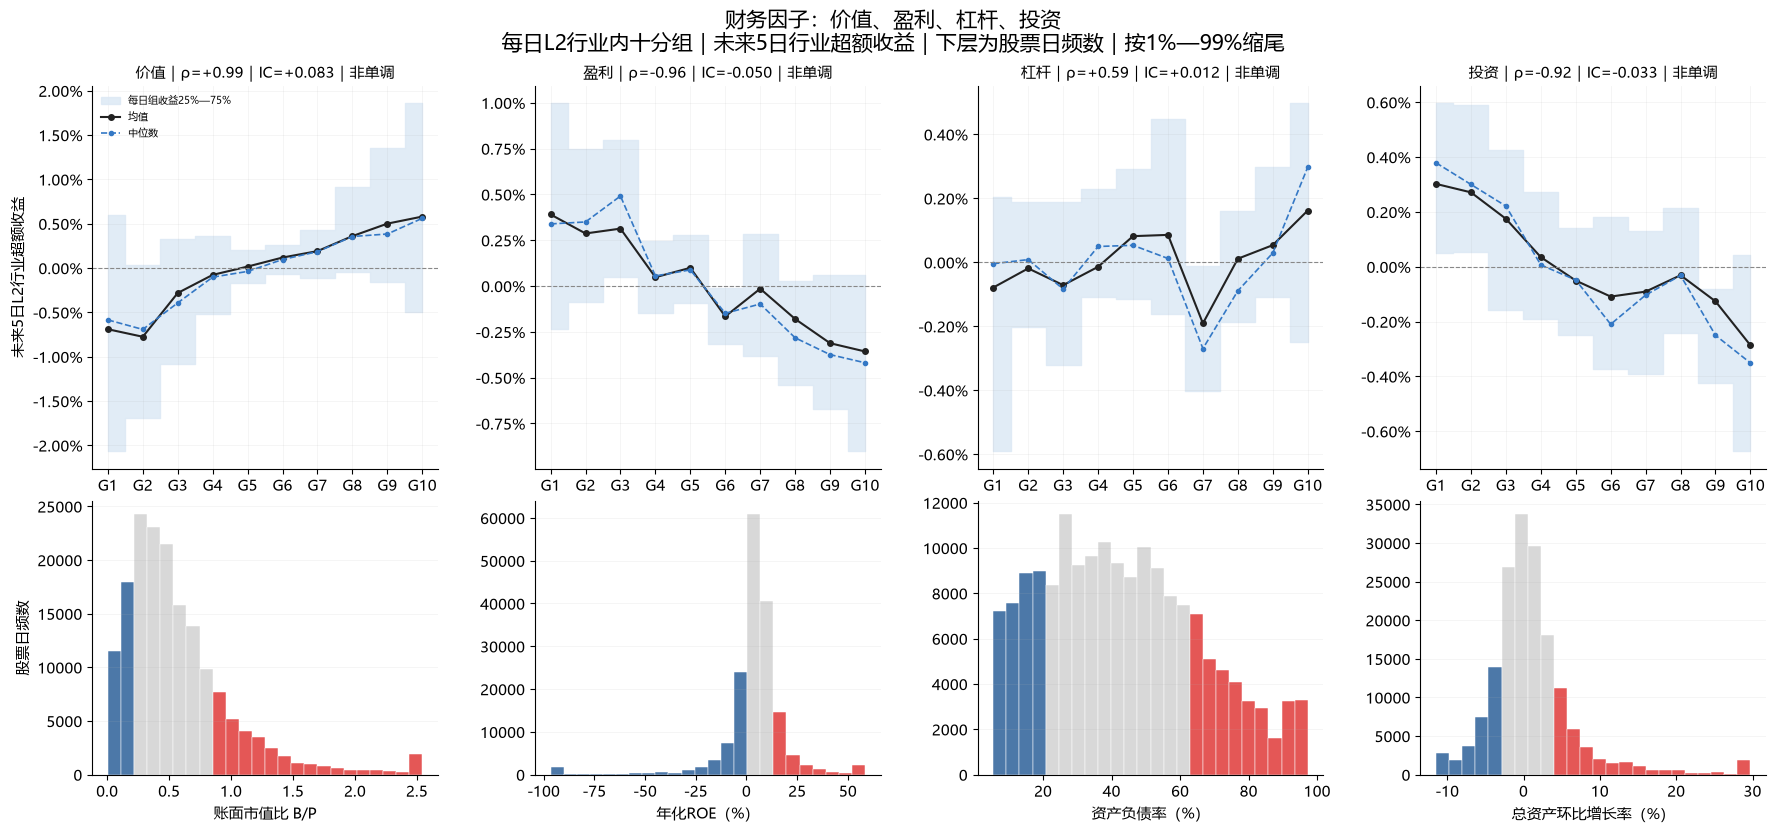

In [21]:
plot_factor_page(
    ["value", "profitability", "leverage", "investment"],
    "财务因子：价值、盈利、杠杆、投资",
)

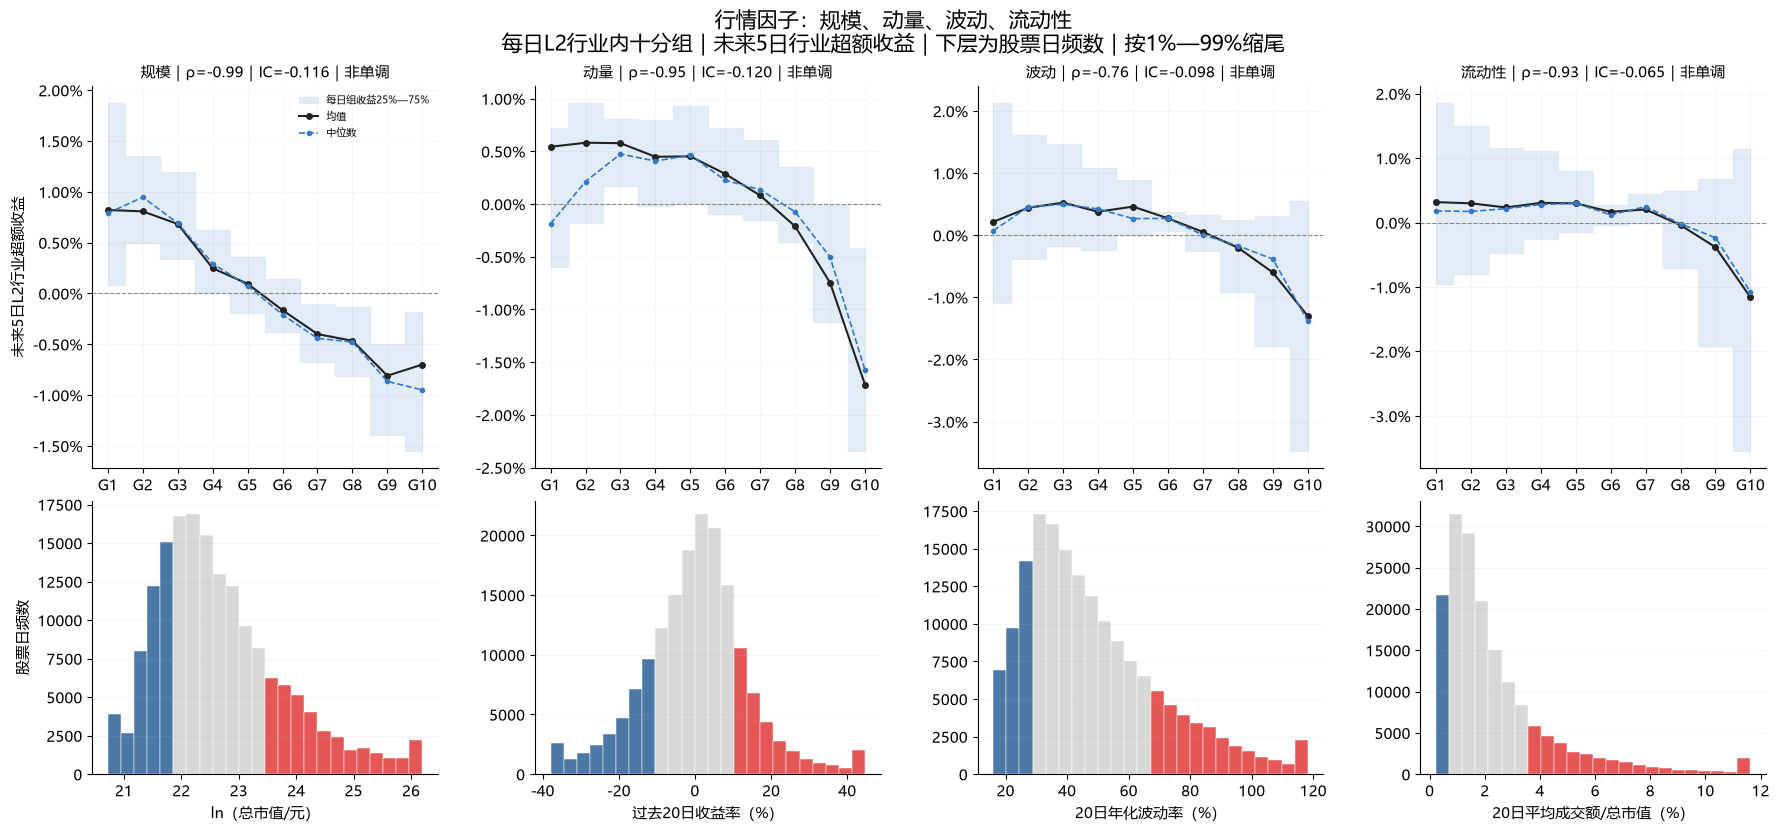

In [22]:
plot_factor_page(
    ["size", "momentum", "volatility", "liquidity"],
    "行情因子：规模、动量、波动、流动性",
)

In [23]:
# 固定前100入选率：每日在L2行业内部按因子分为十组，再统计各组中固定前100股票的占比。
factor_selection_panel = factor_panel.loc[
    factor_panel["time"].between(RESEARCH_START_DATE, END_DATE)
].copy()

selection_group_stats = {}
selection_distribution_values = {}
selection_summary_rows = []

for factor_name in FACTOR_ORDER:
    columns = ["time", "code", "l2_name", "is_top100", factor_name]
    data = factor_selection_panel[columns].dropna().copy()
    data["factor_percentile"] = (
        data.groupby(["time", "l2_name"], observed=True)[factor_name]
        .rank(method="first", pct=True)
    )
    data["factor_group"] = np.ceil(data["factor_percentile"] * 10).clip(1, 10).astype(int)

    daily_group_rate = (
        data.groupby(["time", "factor_group"], observed=True)["is_top100"]
        .mean().rename("selection_rate").reset_index()
    )
    stats = daily_group_rate.groupby("factor_group")["selection_rate"].agg(
        mean="mean", median="median",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        dates="size",
    ).reindex(range(1, 11))
    selection_group_stats[factor_name] = stats
    selection_distribution_values[factor_name] = data[factor_name]

    baseline = data.groupby("time", observed=True)["is_top100"].mean().mean()
    valid_means = stats["mean"].dropna()
    group_rho = pd.Series(valid_means.index, index=valid_means.index).corr(
        valid_means, method="spearman"
    )
    differences = valid_means.diff().dropna()
    if differences.gt(0).all():
        monotonicity = "正向单调"
    elif differences.lt(0).all():
        monotonicity = "负向单调"
    else:
        monotonicity = "非单调"

    selection_summary_rows.append({
        "因子": FACTOR_META[factor_name]["label"],
        "分组单调相关ρ": group_rho,
        "G10-G1（百分点）": (stats.loc[10, "mean"] - stats.loc[1, "mean"]) * 100,
        "整体入选率": baseline,
        "单调性": monotonicity,
    })

selection_summary = pd.DataFrame(selection_summary_rows).set_index("因子")
display(selection_summary.style.format({
    "分组单调相关ρ": "{:+.2f}",
    "G10-G1（百分点）": "{:+.2f}",
    "整体入选率": "{:.2%}",
}))

,分组单调相关ρ,G10-G1（百分点）,整体入选率,单调性
因子,,,,
价值,-0.87,-4.59,2.83%,非单调
盈利,-0.32,+0.68,2.83%,非单调
杠杆,+0.20,+2.25,2.83%,非单调
投资,-0.35,-0.35,2.83%,非单调
规模,-0.66,-0.32,2.83%,非单调
动量,+0.92,+9.53,2.84%,非单调
波动,+0.99,+7.40,2.84%,非单调
流动性,+0.99,+6.83,2.84%,非单调


In [24]:
# # 固定前100入选率图：上层展示十组日度入选率的均值、中位数及四分位区间，下层展示因子分布。
# def plot_selection_page(factor_names, page_title):
#     fig = plt.figure(figsize=(18, 8.5))
#     grid = fig.add_gridspec(
#         2, len(factor_names), height_ratios=[1.05, 0.75],
#         hspace=0.10, wspace=0.28, left=0.055, right=0.985, top=0.87, bottom=0.08,
#     )
#
#     for column, factor_name in enumerate(factor_names):
#         meta = FACTOR_META[factor_name]
#         stats = selection_group_stats[factor_name]
#         summary = selection_summary.loc[meta["label"]]
#         x = np.arange(1, 11)
#
#         top_ax = fig.add_subplot(grid[0, column])
#         top_ax.fill_between(
#             x, stats["q25"], stats["q75"], step="mid",
#             color="#DCE9F5", alpha=0.85, label="每日入选率25%—75%",
#         )
#         top_ax.plot(x, stats["mean"], color="#222222", marker="o",
#                     linewidth=1.5, markersize=4, label="均值")
#         top_ax.plot(x, stats["median"], color="#3478C5", marker="o",
#                     linestyle="--", linewidth=1.2, markersize=3, label="中位数")
#         top_ax.axhline(
#             summary["整体入选率"], color="#E45756", linestyle="--",
#             linewidth=1.0, label="非科技股整体入选率",
#         )
#         top_ax.set_xticks(x, [f"G{i}" for i in x])
#         top_ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
#         top_ax.grid(alpha=0.18)
#         top_ax.set_title(
#             f"{meta['label']}｜ρ={summary['分组单调相关ρ']:+.2f}"
#             f"｜G10-G1={summary['G10-G1（百分点）']:+.2f}个百分点｜{summary['单调性']}",
#             fontsize=11,
#         )
#         if column == 0:
#             top_ax.set_ylabel("固定前100入选率")
#             top_ax.legend(loc="best", fontsize=7, frameon=False)
#
#         bottom_ax = fig.add_subplot(grid[1, column])
#         values = selection_distribution_values[factor_name].dropna() * meta["scale"]
#         lower, upper = values.quantile([0.01, 0.99])
#         values = values.clip(lower, upper)
#         q20, q80 = values.quantile([0.20, 0.80])
#         counts, edges = np.histogram(values, bins=24, density=False)
#         centers = (edges[:-1] + edges[1:]) / 2
#         bar_colors = np.where(
#             centers <= q20, "#4C78A8",
#             np.where(centers >= q80, "#E45756", "#D8D8D8"),
#         )
#         bottom_ax.bar(
#             edges[:-1], counts, width=np.diff(edges), align="edge",
#             color=bar_colors, edgecolor="white", linewidth=0.35,
#         )
#         bottom_ax.set_xlabel(meta["xlabel"])
#         bottom_ax.grid(axis="y", alpha=0.18)
#         if column == 0:
#             bottom_ax.set_ylabel("股票日频数")
#
#     fig.suptitle(
#         f"{page_title}\n固定前100名单｜每日L2行业内十分组｜上层为各组前100入选率｜"
#         f"下层为股票日频数｜按1%—99%缩尾",
#         fontsize=15,
#     )
#     fig.text(
#         0.5, 0.015, "注：该图描述固定前100的因子特征，不是未来收益预测检验。",
#         ha="center", fontsize=9, color="#555555",
#     )
#     plt.show()

In [25]:
# plot_selection_page(
#     ["value", "profitability", "leverage", "investment"],
#     "固定前100入选率：财务因子",
# )

In [26]:
# plot_selection_page(
#     ["size", "momentum", "volatility", "liquidity"],
#     "固定前100入选率：行情因子",
# )

In [27]:
# 入百比例：每日L2行业内按因子五分组，汇总后计算各组前100股票日数占该组全部股票日数的比例。
entry_ratio_group_stats = {}
entry_ratio_summary_rows = []

for factor_name in FACTOR_ORDER:
    columns = ["time", "code", "l2_name", "is_top100", factor_name]
    data = factor_selection_panel[columns].dropna().copy()
    data["factor_percentile"] = (
        data.groupby(["time", "l2_name"], observed=True)[factor_name]
        .rank(method="first", pct=True)
    )
    data["factor_group"] = np.ceil(data["factor_percentile"] * 5).clip(1, 5).astype(int)

    stats = data.groupby("factor_group", observed=True).agg(
        constituent_stock_days=("code", "size"),
        selected_stock_days=("is_top100", "sum"),
    ).reindex(range(1, 6), fill_value=0)
    stats["entry_ratio"] = stats["selected_stock_days"] / stats["constituent_stock_days"]
    entry_ratio_group_stats[factor_name] = stats

    baseline = data["is_top100"].mean()
    valid_rates = stats["entry_ratio"].dropna()
    group_rho = pd.Series(valid_rates.index, index=valid_rates.index).corr(
        valid_rates, method="spearman"
    )
    entry_ratio_summary_rows.append({
        "因子": FACTOR_META[factor_name]["label"],
        "分组单调相关ρ": group_rho,
        "最高组-最低组（百分点）": (stats.loc[5, "entry_ratio"] - stats.loc[1, "entry_ratio"]) * 100,
        "整体入百比例": baseline,
    })

entry_ratio_summary = pd.DataFrame(entry_ratio_summary_rows).set_index("因子")
display(entry_ratio_summary.style.format({
    "分组单调相关ρ": "{:+.2f}",
    "最高组-最低组（百分点）": "{:+.2f}",
    "整体入百比例": "{:.2%}",
}))

,分组单调相关ρ,最高组-最低组（百分点）,整体入百比例
因子,,,
价值,-0.90,-3.41,2.83%
盈利,-0.70,-0.71,2.83%
杠杆,+0.30,+1.62,2.83%
投资,-0.30,-0.28,2.83%
规模,-0.90,-1.89,2.83%
动量,+0.90,+5.53,2.84%
波动,+1.00,+5.06,2.84%
流动性,+1.00,+4.61,2.84%


In [28]:
# 入百比例图同样保留上下双图结构：上层为五分组柱状图，下层为因子分布。
ENTRY_RATIO_GROUP_LABELS = ["最低20%", "较低20%", "中间20%", "较高20%", "最高20%"]

def plot_entry_ratio_page(factor_names, page_title):
    fig = plt.figure(figsize=(18, 8.5))
    grid = fig.add_gridspec(
        2, len(factor_names), height_ratios=[1.05, 0.75],
        hspace=0.20, wspace=0.28, left=0.055, right=0.985, top=0.87, bottom=0.09,
    )

    for column, factor_name in enumerate(factor_names):
        meta = FACTOR_META[factor_name]
        stats = entry_ratio_group_stats[factor_name]
        summary = entry_ratio_summary.loc[meta["label"]]
        x = np.arange(5)
        rates = stats["entry_ratio"].to_numpy()

        top_ax = fig.add_subplot(grid[0, column])
        bars = top_ax.bar(x, rates, color="#4C78A8", width=0.78)
        top_ax.axhline(
            summary["整体入百比例"], color="#E45756", linestyle="--",
            linewidth=1.1, label="非科技股整体入百比例",
        )
        upper = max(np.nanmax(rates), summary["整体入百比例"]) * 1.30
        top_ax.set_ylim(0, upper)
        for bar, rate in zip(bars, rates):
            top_ax.text(
                bar.get_x() + bar.get_width() / 2, bar.get_height() + upper * 0.025,
                f"{rate:.2%}", ha="center", va="bottom", fontsize=8,
            )
        top_ax.set_xticks(x, ENTRY_RATIO_GROUP_LABELS, rotation=0, ha="right", fontsize=8)
        top_ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
        top_ax.grid(axis="y", alpha=0.18)
        top_ax.set_axisbelow(True)
        top_ax.set_title(
            f"{meta['label']}｜ρ={summary['分组单调相关ρ']:+.2f}"
            f"｜最高-最低={summary['最高组-最低组（百分点）']:+.2f}个百分点",
            fontsize=11,
        )
        if column == 0:
            top_ax.set_ylabel("入百比例")
            top_ax.legend(loc="best", fontsize=7, frameon=False)

        bottom_ax = fig.add_subplot(grid[1, column])
        values = selection_distribution_values[factor_name].dropna() * meta["scale"]
        lower, upper_value = values.quantile([0.01, 0.99])
        values = values.clip(lower, upper_value)
        q20, q80 = values.quantile([0.20, 0.80])
        counts, edges = np.histogram(values, bins=24, density=False)
        centers = (edges[:-1] + edges[1:]) / 2
        bar_colors = np.where(
            centers <= q20, "#4C78A8",
            np.where(centers >= q80, "#E45756", "#D8D8D8"),
        )
        bottom_ax.bar(
            edges[:-1], counts, width=np.diff(edges), align="edge",
            color=bar_colors, edgecolor="white", linewidth=0.35,
        )
        bottom_ax.set_xlabel(meta["xlabel"])
        bottom_ax.grid(axis="y", alpha=0.18)
        if column == 0:
            bottom_ax.set_ylabel("股票日频数")

    fig.suptitle(
        f"{page_title}\n每日L2行业内按因子值五分组｜下层为股票日频数｜按1%—99%缩尾",
        fontsize=15,
    )
    fig.text(
        0.5, 0.02,
        "入百比例 = 各组中属于固定前100的股票日数 ÷ 该组全部股票日数；红线为相同有效样本的整体入百比例。",
        ha="center", fontsize=9, color="#555555",
    )
    plt.show()

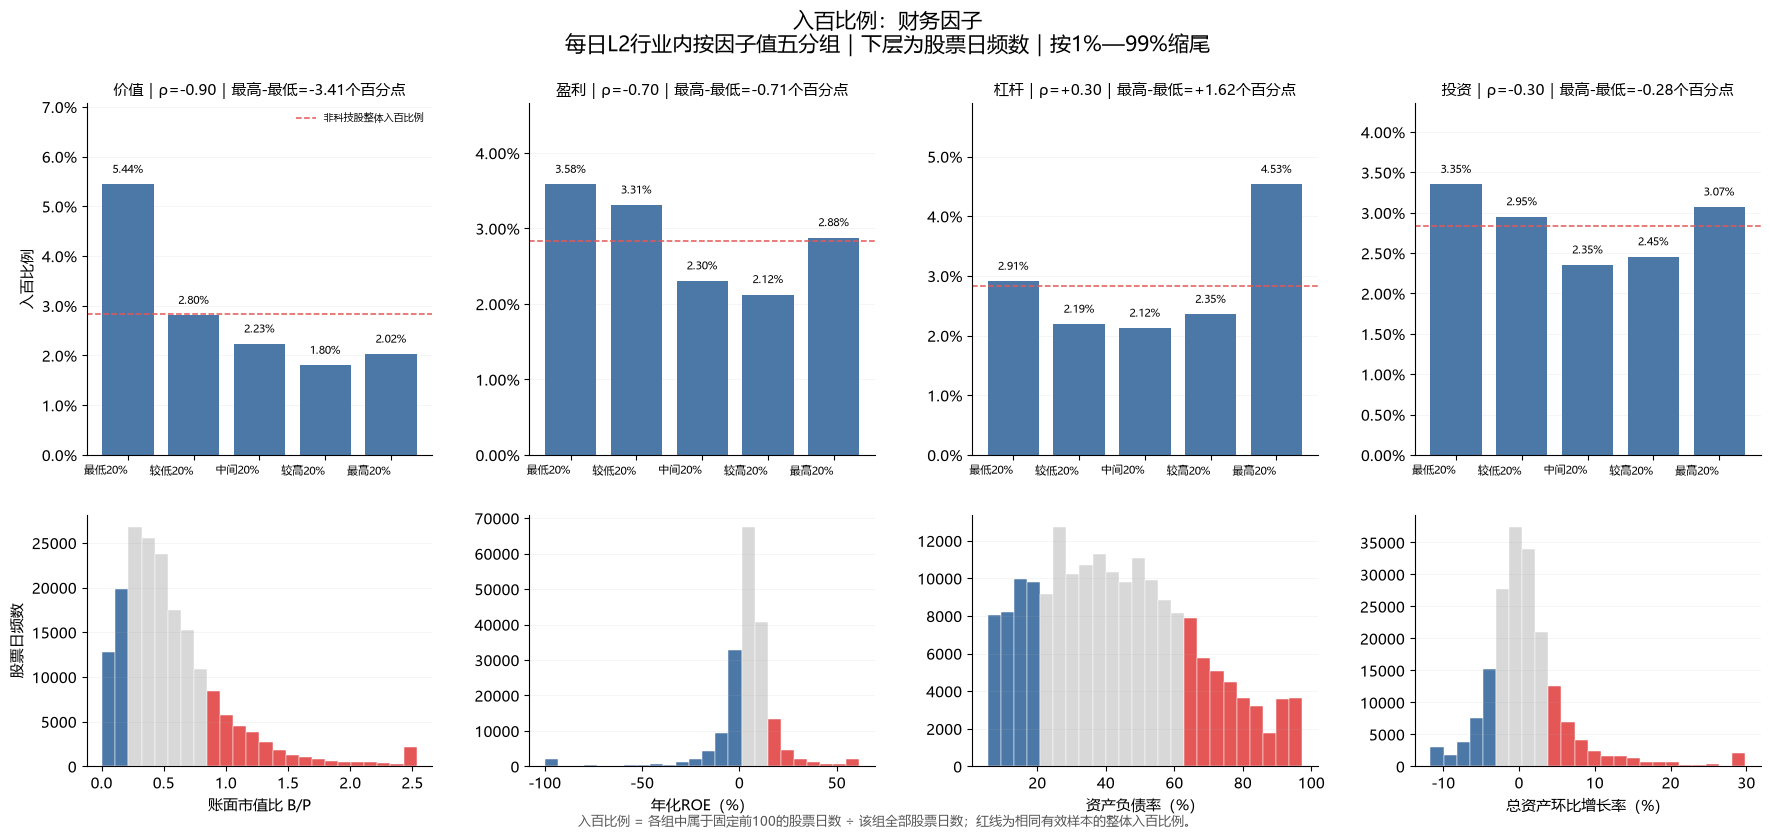

In [29]:
plot_entry_ratio_page(
    ["value", "profitability", "leverage", "investment"],
    "入百比例：财务因子",
)

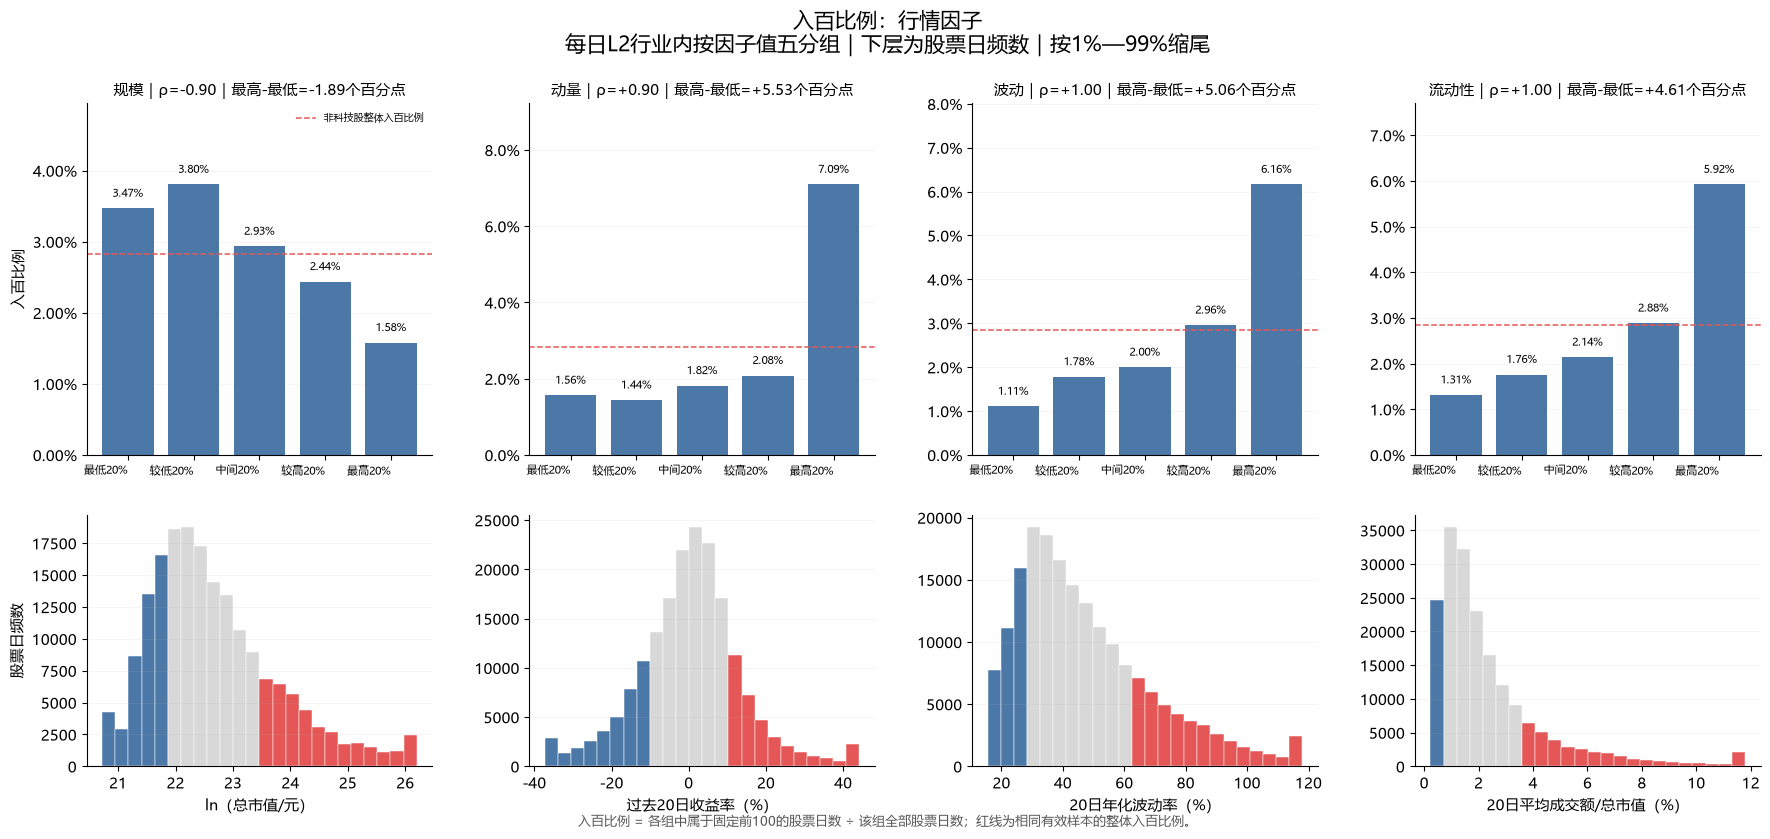

In [30]:
plot_entry_ratio_page(
    ["size", "momentum", "volatility", "liquidity"],
    "入百比例：行情因子",
)

## 形态篇章

本篇直接复用统一预处理的共同前100名单；形态识别和价格片段构造在本篇内部完成。


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.signal as signal

def dynamic_order(n):
    """根据序列长度动态确定峰谷检测的 order（窗口半径）。
    order 过小 → 噪声峰谷过多；过大 → 漏掉真实转折。
    经验：取序列长度的 ~1/12，并夹在 [2, n//3] 之间。"""
    return max(2, min(n // 3, round(n / 12)))


def find_turning_points(s):
    """用 scipy.argrelextrema 找局部峰/谷，并补全首尾、保证峰谷交替。
    返回 (peaks, troughs) 索引数组。"""
    values = np.asarray(s.values, dtype=float)
    n = len(values)
    order = dynamic_order(n)
    peaks = signal.argrelextrema(values, np.greater, order=order)[0]
    troughs = signal.argrelextrema(-values, np.greater, order=order)[0]
    if len(troughs) == 0:
        troughs = np.insert(troughs, 0, int(np.argmin(values)))
    if len(peaks) == 0:
        peaks = np.insert(peaks, 0, int(np.argmax(values)))
    if peaks[0] != 0 and troughs[0] != 0:
        if peaks[0] > troughs[0]:
            peaks = np.insert(peaks, 0, 0)
        else:
            troughs = np.insert(troughs, 0, 0)
    if peaks[-1] > troughs[-1]:
        if peaks[-1] != n - 1:
            min_idx = int(np.argmin(values[peaks[-1]:]) + peaks[-1])
            troughs = np.append(troughs, min_idx)
            if min_idx != n - 1:
                peaks = np.append(peaks, n - 1)
    else:
        if troughs[-1] != n - 1:
            max_idx = int(np.argmax(values[troughs[-1]:]) + troughs[-1])
            peaks = np.append(peaks, max_idx)
            if max_idx != n - 1:
                troughs = np.append(troughs, n - 1)
    for _ in range(3):
        fixed = True
        for p in range(len(peaks) - 1):
            if not any(peaks[p] < pf < peaks[p + 1] for pf in troughs if pf > 0):
                min_idx = int(np.argmin(values[peaks[p]:peaks[p + 1]]) + peaks[p])
                troughs = np.sort(np.unique(np.append(troughs, min_idx)))
                fixed = False
        for q in range(len(troughs) - 1):
            if not any(troughs[q] < pe < troughs[q + 1] for pe in peaks if pe > 0):
                max_idx = int(np.argmax(values[troughs[q]:troughs[q + 1]]) + troughs[q])
                peaks = np.sort(np.unique(np.append(peaks, max_idx)))
                fixed = False
        if fixed:
            break
    return list(peaks), list(troughs)


def detect_shape(s, amp_thresh=0.03, retrace_thresh=0.05):
    """基于峰谷检测辅助判定形态：先按首尾涨跌定主基调，再用峰谷结构区分
    单边 / 带回调 / V字 / A字 / 震荡上行 / 震荡下行 / 横盘等。"""
    if s is None or len(s) == 0:
        return '数据不足'
    s = s.astype(float)
    n = len(s)
    if n < 5 or s.iloc[0] == 0:
        return '数据不足'
    first, last = s.iloc[0], s.iloc[-1]
    total = last / first - 1.0
    amp = (s.max() - s.min()) / first
    if amp < amp_thresh:
        return '横盘震荡'
    peaks, troughs = find_turning_points(s)
    pts = sorted(set(peaks) | set(troughs))
    up_seg = 0; dn_seg = 0
    for i in range(1, len(pts)):
        if s.iloc[pts[i]] >= s.iloc[pts[i - 1]]:
            up_seg += 1
        else:
            dn_seg += 1
    i_hi = int(s.values.argmax()); i_lo = int(s.values.argmin())
    p_hi = i_hi / (n - 1); p_lo = i_lo / (n - 1)
    run_max = s.cummax(); run_min = s.cummin()
    max_dd = ((s - run_max) / run_max).min()
    max_reb = ((s - run_min) / run_min).max()
    pk_vals = [s.iloc[i] for i in peaks]
    tr_vals = [s.iloc[i] for i in troughs]
    higher_highs = len(pk_vals) >= 2 and pk_vals[-1] > pk_vals[0]
    higher_lows = len(tr_vals) >= 2 and tr_vals[-1] > tr_vals[0]
    lower_highs = len(pk_vals) >= 2 and pk_vals[-1] < pk_vals[0]
    lower_lows = len(tr_vals) >= 2 and tr_vals[-1] < tr_vals[0]
    rng = s.iloc[i_hi] - s.iloc[i_lo]
    reb_pos = (last - s.iloc[i_lo]) / rng if rng != 0 else 0.5
    if total < 0.05:
        if p_lo < 0.6 and max_reb > retrace_thresh and reb_pos > 0.5:
            return 'V字反转'
        if p_hi < 0.5 and max_dd < -retrace_thresh:
            return '下行带反弹' if max_reb > retrace_thresh else 'A字回落'
    if total > 0.02:
        if up_seg >= 2 and higher_lows and higher_highs:
            return '震荡上行'
        return '上行带回调' if max_dd < -retrace_thresh else '单边上行'
    if total < -0.02:
        if dn_seg >= 2 and lower_highs and lower_lows:
            return '震荡下行'
        return '下行带反弹' if max_reb > retrace_thresh else '单边下行'
    return '横盘震荡'

In [32]:
# 形态判断只采用启动前20个交易日。
SHAPE_WINDOW_DAYS = 20
shape_trade_days = pd.DatetimeIndex(sorted(prices["time"].unique()))
shape_pre_days = shape_trade_days[shape_trade_days < RESEARCH_START_DATE]

shape_segments = {
    "启动前20日": shape_pre_days[-SHAPE_WINDOW_DAYS:],
}
shape_segment_table = pd.DataFrame([
    {"价格片段": name, "起始日": days[0], "结束日": days[-1], "交易日数": len(days)}
    for name, days in shape_segments.items()
])
print("7月1日前可用交易日数：", len(shape_pre_days))
display(shape_segment_table)

7月1日前可用交易日数： 39


,价格片段,起始日,结束日,交易日数
0,启动前20日,2026-06-02,2026-06-30,20


In [33]:
# 对固定前100逐股判断启动前20日价格形态。
shape_rows = []
for segment_name, segment_days in shape_segments.items():
    segment_start, segment_end = segment_days[0], segment_days[-1]
    for code in top100_sample["code"]:
        price_series = (
            prices.loc[
                prices["code"].eq(code)
                & prices["time"].between(segment_start, segment_end),
                ["time", "close"],
            ]
            .sort_values("time")["close"]
            .dropna()
        )
        shape_rows.append({
            "价格片段": segment_name,
            "code": code,
            "有效交易日数": len(price_series),
            "片段涨跌幅": price_series.iloc[-1] / price_series.iloc[0] - 1,
            "价格形态": detect_shape(price_series, 0.03, 0.05),
        })

top100_shape_long = pd.DataFrame(shape_rows).merge(
    top100_sample[["code", "股票名称", "big5_l1", "big5_l2", "l2_name", "return_pct"]],
    on="code", how="left", validate="many_to_one",
)
assert top100_shape_long["有效交易日数"].ge(5).all()

SHAPE_ORDER = [
    "单边上行", "上行带回调", "震荡上行", "V字反转", "横盘震荡",
    "A字回落", "下行带反弹", "震荡下行", "单边下行", "数据不足",
]
shape_counts = (
    top100_shape_long.groupby(["价格片段", "价格形态"], observed=True).size()
    .unstack(fill_value=0)
    .reindex(index=shape_segments, columns=SHAPE_ORDER, fill_value=0)
)
shape_shares = shape_counts.div(shape_counts.sum(axis=1), axis=0)
shape_summary = shape_counts.astype(str) + "（" + shape_shares.map(lambda x: f"{x:.0%}") + "）"
display(shape_summary)

top100_shape_table = (
    top100_shape_long.pivot(index="code", columns="价格片段", values="价格形态")
    .reindex(columns=shape_segments)
    .reset_index()
    .merge(
        top100_sample[["code", "股票名称", "big5_l1", "big5_l2", "l2_name", "return_pct"]],
        on="code", how="left", validate="one_to_one",
    )
    .sort_values("return_pct", ascending=False)
)
top100_shape_table = top100_shape_table[[
    "code", "股票名称",
    *[column for column in top100_shape_table.columns if column not in ["code", "股票名称"]],
]]
display(top100_shape_table.style.format({"return_pct": "{:+.2f}%"}))

价格形态,单边上行,上行带回调,震荡上行,V字反转,横盘震荡,A字回落,下行带反弹,震荡下行,单边下行,数据不足
价格片段,,,,,,,,,,
启动前20日,0（0%）,3（3%）,4（4%）,4（4%）,3（3%）,42（42%）,44（44%）,0（0%）,0（0%）,0（0%）


,code,股票名称,启动前20日,big5_l1,big5_l2,l2_name,return_pct
49,301234.XSHE,五洲医疗,下行带反弹,医药,器械与服务,医疗器械,+202.83%
85,603221.XSHG,爱丽家居,A字回落,消费,可选消费,家居用品,+171.95%
31,300010.XSHE,ST豆神,下行带反弹,消费,消费服务与零售,教育,+164.71%
53,600127.XSHG,金健米业,A字回落,消费,必选消费,农产品加工,+160.58%
88,603580.XSHG,艾艾精工,横盘震荡,周期,基础原材料,塑料制品,+158.77%
78,601086.XSHG,国芳集团,A字回落,消费,消费服务与零售,零售,+146.61%
28,002827.XSHE,高争民爆,下行带反弹,周期,基础原材料,化学制品,+140.93%
41,300862.XSHE,蓝盾光电,下行带反弹,周期,资源与能源,环保设备,+140.40%
60,600371.XSHG,万向德农,A字回落,消费,必选消费,种植业与林业,+136.48%
69,600664.XSHG,哈药股份,下行带反弹,医药,制药与研发,化学制药,+133.78%


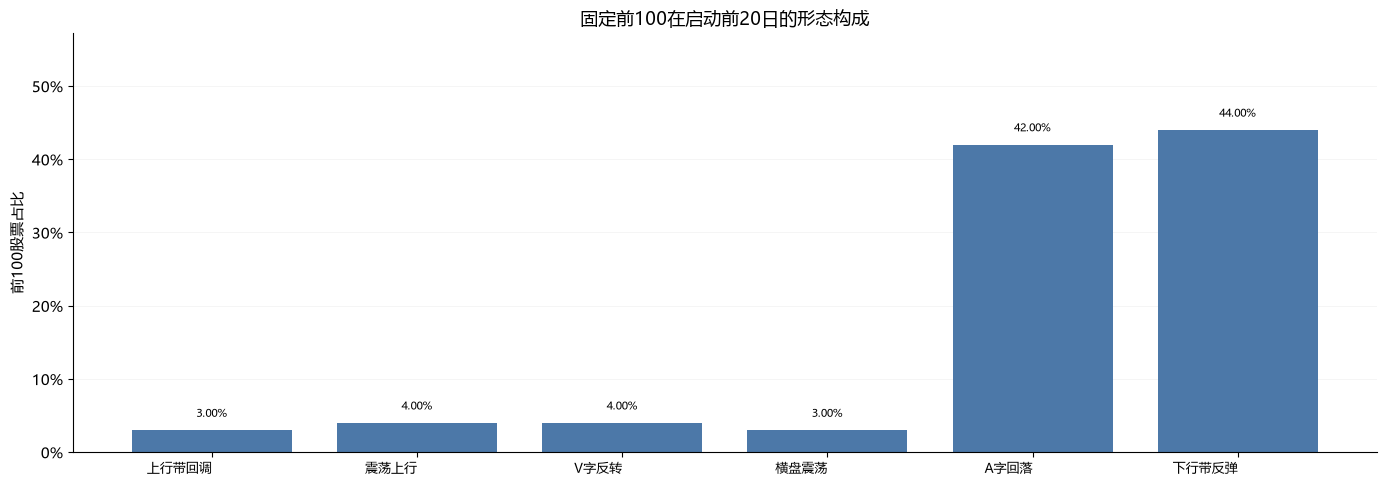

In [34]:
# 前100在启动前20日的形态构成；柱状图沿用“入百比例”上子图样式。
shape_plot = shape_shares.loc["启动前20日"]
shape_plot = shape_plot.loc[shape_plot.gt(0)]
x = np.arange(len(shape_plot))
rates = shape_plot.to_numpy()

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(x, rates, color="#4C78A8", width=0.78)
upper = np.nanmax(rates) * 1.30
ax.set_ylim(0, upper)
for bar, rate in zip(bars, rates):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + upper * 0.025,
        f"{rate:.2%}", ha="center", va="bottom", fontsize=8,
    )
ax.set_xticks(x, shape_plot.index, rotation=0, ha="right", fontsize=9)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.set_ylabel("前100股票占比")
ax.set_title("固定前100在启动前20日的形态构成")
ax.grid(axis="y", alpha=0.18)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()


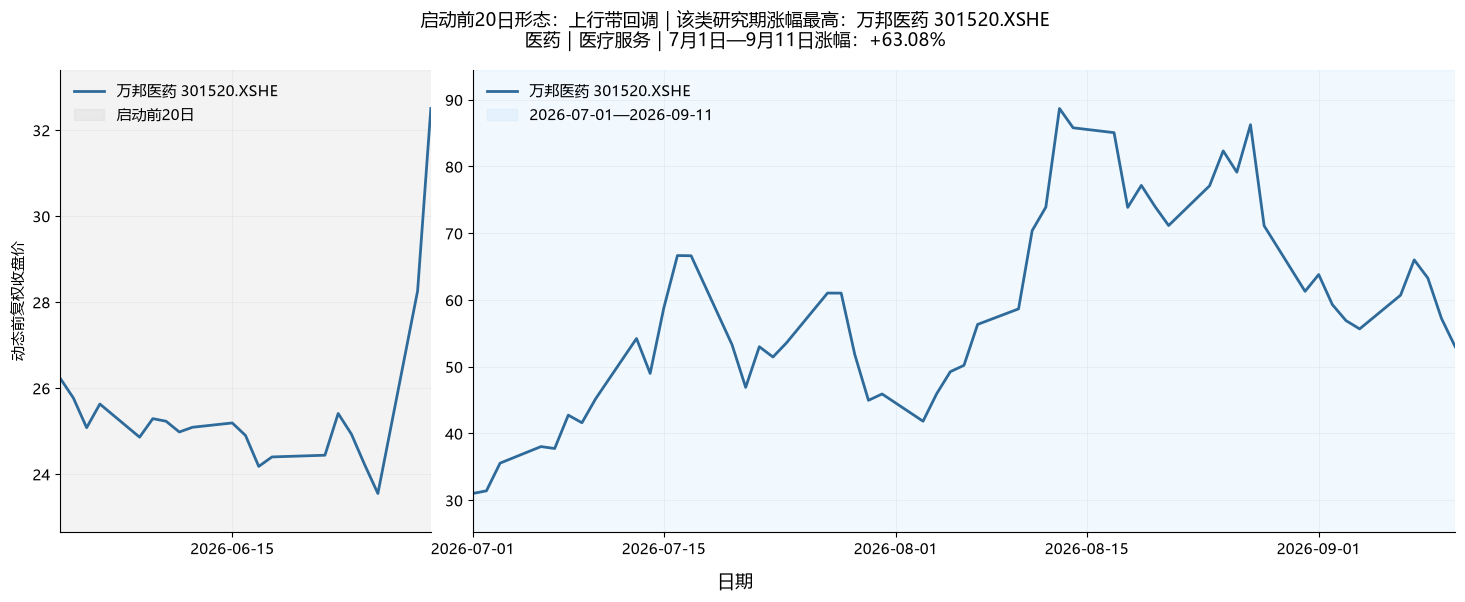

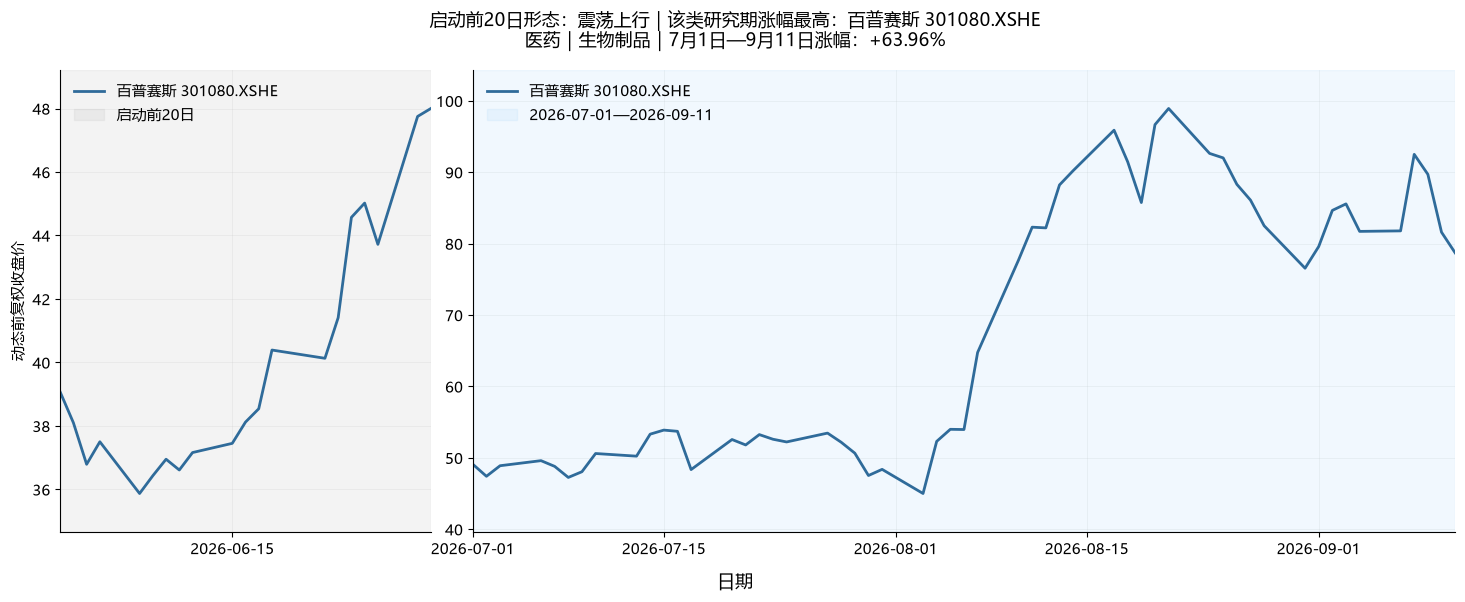

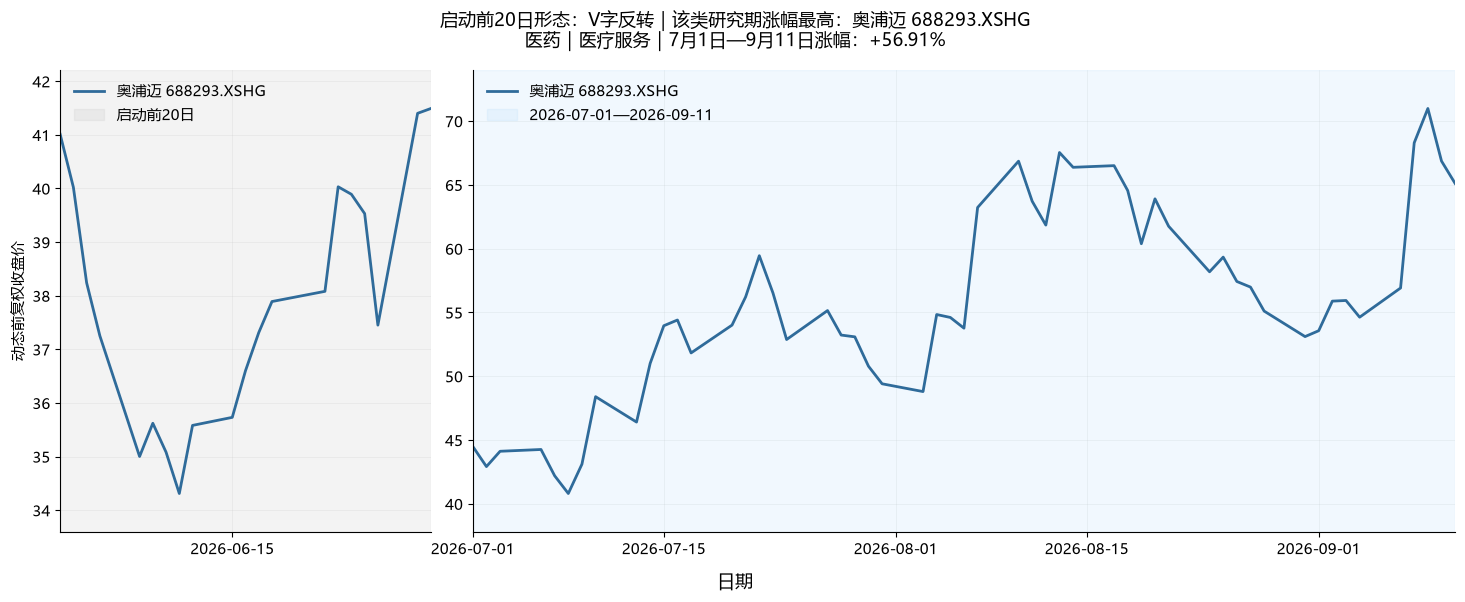

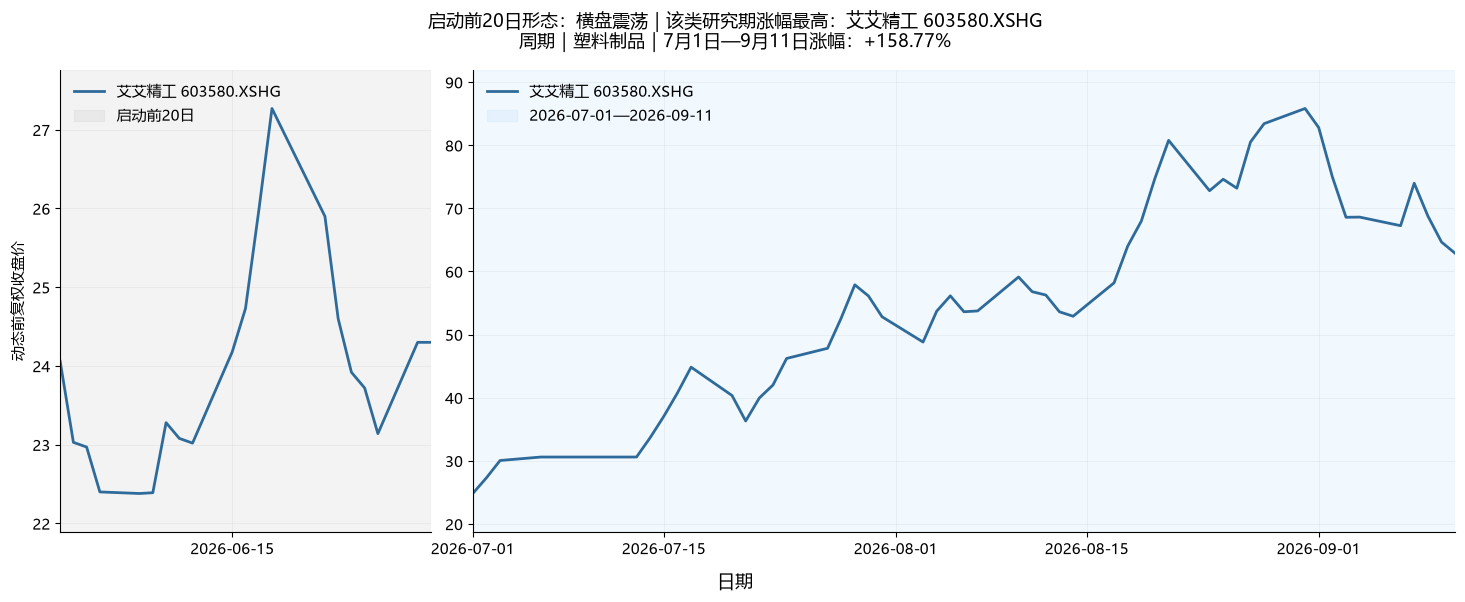

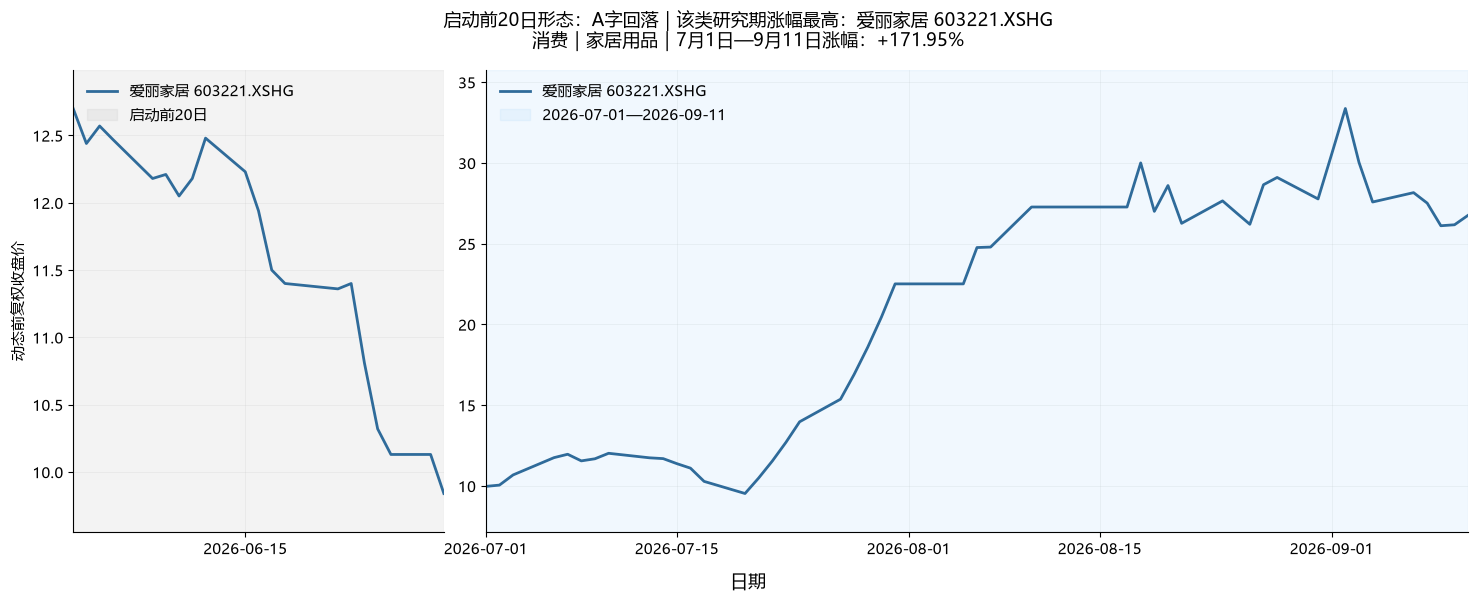

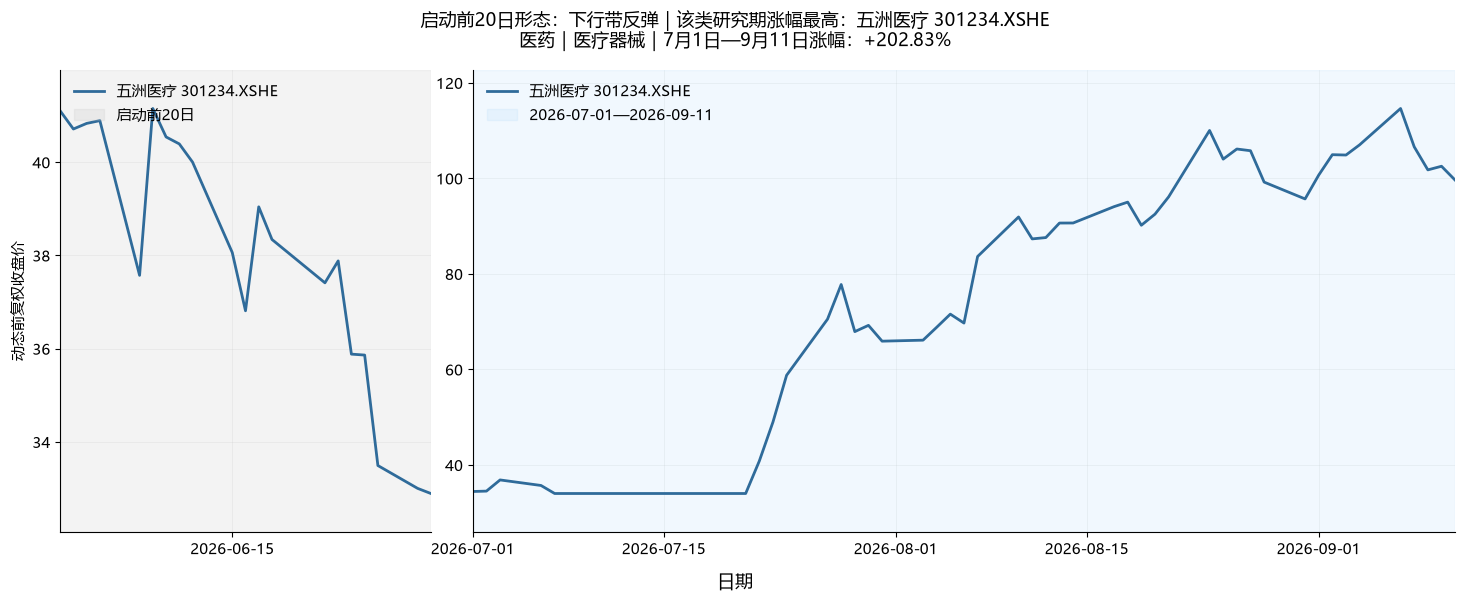

In [37]:
# 启动前20日各形态中，选取7月1日至9月11日涨幅最高的股票，逐图展示完整价格轨迹。
import matplotlib.dates as mdates

startup_shape_winners = (
    top100_shape_long.loc[
        top100_shape_long["价格片段"].eq("启动前20日")
    ]
    .sort_values(
        ["价格形态", "return_pct", "code"],
        ascending=[True, False, True],
    )
    .drop_duplicates("价格形态")
    .set_index("价格形态")
    .reindex(SHAPE_ORDER)
    .dropna(subset=["code"])
)

full_path_start = shape_segments["启动前20日"][0]
pre_segment_end = shape_segments["启动前20日"][-1]

for shape_name, winner in startup_shape_winners.iterrows():
    code = winner["code"]
    stock_label = f"{winner['股票名称']} {code}"
    price_path = (
        prices.loc[
            prices["code"].eq(code)
            & prices["time"].between(full_path_start, END_DATE),
            ["time", "close"],
        ]
        .sort_values("time")
    )

    pre_path = price_path.loc[
        price_path["time"].between(full_path_start, pre_segment_end)
    ]
    study_path = price_path.loc[
        price_path["time"].between(RESEARCH_START_DATE, END_DATE)
    ]

    fig, (ax_pre, ax_study) = plt.subplots(
        1, 2, figsize=(18, 6), sharey=False, constrained_layout=False,
        gridspec_kw={
            "width_ratios": [len(pre_path), len(study_path)],
            "wspace": 0.062,   # 左右两图间隔调小
        },
    )

    ax_pre.plot(
        pre_path["time"], pre_path["close"],
        color="#2F6B9A", linewidth=2, label=stock_label,
    )
    ax_pre.axvspan(
        full_path_start, pre_segment_end,
        color="#BDBDBD", alpha=0.18, label="启动前20日",
    )
    ax_pre.set_xlim(full_path_start, pre_segment_end)

    ax_study.plot(
        study_path["time"], study_path["close"],
        color="#2F6B9A", linewidth=2, label=stock_label,
    )
    ax_study.axvspan(
        RESEARCH_START_DATE, END_DATE,
        color="#90CAF9", alpha=0.12, label="2026-07-01—2026-09-11",
    )

    ax_study.set_xlim(RESEARCH_START_DATE, END_DATE)

    fig.suptitle(
        f"启动前20日形态：{shape_name}｜该类研究期涨幅最高：{stock_label}\n"
        f"{winner['big5_l1']}｜{winner['l2_name']}｜"
        f"7月1日—9月11日涨幅：{winner['return_pct']:+.2f}%"
    )
    # ax_pre.text(
    #     0.98, 0.97, "启动前20日", transform=ax_pre.transAxes,
    #     ha="right", va="top", fontsize=10, color="#555555",
    # )
    # ax_study.text(
    #     0.98, 0.97, "2026-07-01—2026-09-11", transform=ax_study.transAxes,
    #     ha="right", va="top", fontsize=10, color="#555555",
    # )
    ax_pre.set_ylabel("动态前复权收盘价")
    ax_study.set_ylabel("")   # 右图不显示 y 轴标签，但保留刻度

    ax_pre.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=3, maxticks=4))
    ax_study.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=5, maxticks=8))
    for ax in (ax_pre, ax_study):
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
        ax.margins(y=0.10)
        ax.grid(alpha=0.2)
        ax.set_axisbelow(True)
        ax.legend(frameon=False, loc="upper left")
        ax.tick_params(axis="x", labelrotation=0)

    fig.supxlabel("日期")
    plt.show()

## 前100个股行业、因子与形态汇总表

每只股票一行。八个因子和总市值统一取2026-07-01截面；形态采用启动前20个交易日的判断结果。最终仅保留下表明确列示的18个字段。


In [36]:
# 因子及总市值统一取2026-07-01截面。
FINAL_FACTOR_DATE = RESEARCH_START_DATE
top100_factor_snapshot = factor_panel.loc[
    factor_panel["time"].eq(FINAL_FACTOR_DATE)
    & factor_panel["code"].isin(top100_codes),
    ["code", "time", "market_cap", *FACTOR_ORDER],
].copy()
assert len(top100_factor_snapshot) == 100
assert top100_factor_snapshot["code"].is_unique
assert top100_factor_snapshot[FACTOR_ORDER].notna().all().all()

# 形态仅保留启动前20日价格形态。
top100_shape_snapshot = (
    top100_shape_long.loc[
        top100_shape_long["价格片段"].eq("启动前20日"),
        ["code", "价格形态"],
    ]
    .rename(columns={"价格形态": "启动前20日价格形态"})
)
assert len(top100_shape_snapshot) == 100
assert top100_shape_snapshot["code"].is_unique

top100_full_table = (
    top100_sample[["code", "股票名称", "big5_l1", "big5_l2", "l2_name", "return_pct"]]
    .sort_values(["return_pct", "code"], ascending=[False, True])
    .reset_index(drop=True)
    .merge(top100_factor_snapshot, on="code", how="left", validate="one_to_one")
    .merge(top100_shape_snapshot, on="code", how="left", validate="one_to_one")
    .rename(columns={
        "code": "股票代码",
        "big5_l1": "五大板块",
        "big5_l2": "五大板块二级板块",
        "l2_name": "同花顺L2行业",
        "return_pct": "研究区间涨跌幅（%）",
        "time": "因子截面日期",
        "market_cap": "因子截面总市值（亿元）",
        "value": "价值因子：B/P",
        "profitability": "盈利因子：年化ROE（%）",
        "leverage": "杠杆因子：资产负债率（%）",
        "investment": "投资因子：总资产环比（%）",
        "size": "规模因子：ln（总市值/元）",
        "momentum": "动量因子：过去20日收益率（%）",
        "volatility": "波动因子：20日年化波动率（%）",
        "liquidity": "流动性因子：20日平均成交额/总市值（%）",
    })
)
top100_full_table.insert(0, "排名", range(1, len(top100_full_table) + 1))
top100_full_table["因子截面总市值（亿元）"] /= 1e8
for column in [
    "盈利因子：年化ROE（%）", "杠杆因子：资产负债率（%）",
    "投资因子：总资产环比（%）", "动量因子：过去20日收益率（%）",
    "波动因子：20日年化波动率（%）",
    "流动性因子：20日平均成交额/总市值（%）",
]:
    top100_full_table[column] *= 100

FINAL_TABLE_COLUMNS = [
    "排名", "股票代码", "股票名称", "五大板块", "五大板块二级板块",
    "同花顺L2行业", "研究区间涨跌幅（%）", "因子截面日期",
    "因子截面总市值（亿元）", "价值因子：B/P", "盈利因子：年化ROE（%）",
    "杠杆因子：资产负债率（%）", "投资因子：总资产环比（%）",
    "规模因子：ln（总市值/元）", "动量因子：过去20日收益率（%）",
    "波动因子：20日年化波动率（%）",
    "流动性因子：20日平均成交额/总市值（%）", "启动前20日价格形态",
]
top100_full_table = top100_full_table[FINAL_TABLE_COLUMNS]
assert len(top100_full_table) == 100
assert top100_full_table["股票代码"].is_unique
assert top100_full_table.columns.tolist() == FINAL_TABLE_COLUMNS
assert top100_full_table.notna().all().all()

display(
    top100_full_table.style
    .hide(axis="index")
    .format({
        "研究区间涨跌幅（%）": "{:+.2f}",
        "因子截面总市值（亿元）": "{:,.2f}",
        "价值因子：B/P": "{:.4f}",
        "盈利因子：年化ROE（%）": "{:.2f}",
        "杠杆因子：资产负债率（%）": "{:.2f}",
        "投资因子：总资产环比（%）": "{:+.2f}",
        "规模因子：ln（总市值/元）": "{:.4f}",
        "动量因子：过去20日收益率（%）": "{:+.2f}",
        "波动因子：20日年化波动率（%）": "{:.2f}",
        "流动性因子：20日平均成交额/总市值（%）": "{:.4f}",
    }, na_rep="—")
    .set_caption("非科技股涨幅前100：行业、2026-07-01因子截面与启动前20日价格形态")
)


排名,股票代码,股票名称,五大板块,五大板块二级板块,同花顺L2行业,研究区间涨跌幅（%）,因子截面日期,因子截面总市值（亿元）,价值因子：B/P,盈利因子：年化ROE（%）,杠杆因子：资产负债率（%）,投资因子：总资产环比（%）,规模因子：ln（总市值/元）,动量因子：过去20日收益率（%）,波动因子：20日年化波动率（%）,流动性因子：20日平均成交额/总市值（%）,启动前20日价格形态
1,301234.XSHE,五洲医疗,医药,器械与服务,医疗器械,+202.83,2026-07-01 00:00:00,23.41,0.3286,4.21,9.94,-1.73,21.5737,-16.25,64.02,2.6412,下行带反弹
2,603221.XSHG,爱丽家居,消费,可选消费,家居用品,+171.95,2026-07-01 00:00:00,24.45,0.6424,-3.74,29.16,-6.23,21.6175,-21.50,31.19,1.1534,A字回落
3,300010.XSHE,ST豆神,消费,消费服务与零售,教育,+164.71,2026-07-01 00:00:00,44.23,0.3918,-12.94,30.13,-3.69,22.2100,-28.67,59.96,2.3646,下行带反弹
4,600127.XSHG,金健米业,消费,必选消费,农产品加工,+160.58,2026-07-01 00:00:00,34.21,0.1963,0.10,67.57,+19.32,21.9531,-14.03,24.62,1.7715,A字回落
5,603580.XSHG,艾艾精工,周期,基础原材料,塑料制品,+158.77,2026-07-01 00:00:00,32.54,0.1399,2.46,38.24,-2.10,21.9031,+3.16,52.11,0.9381,横盘震荡
6,601086.XSHG,国芳集团,消费,消费服务与零售,零售,+146.61,2026-07-01 00:00:00,45.49,0.3583,10.28,44.13,+4.21,22.2381,-13.54,43.41,1.7128,A字回落
7,002827.XSHE,高争民爆,周期,基础原材料,化学制品,+140.93,2026-07-01 00:00:00,67.60,0.1597,3.53,50.38,+7.24,22.6343,-12.07,45.97,1.3883,下行带反弹
8,300862.XSHE,蓝盾光电,周期,资源与能源,环保设备,+140.40,2026-07-01 00:00:00,38.40,0.5106,-1.76,16.09,-2.40,22.0688,-7.31,40.66,2.8220,下行带反弹
9,600371.XSHG,万向德农,消费,必选消费,种植业与林业,+136.48,2026-07-01 00:00:00,19.05,0.2817,0.78,16.78,-4.90,21.3676,-12.97,32.25,1.5313,A字回落
10,600664.XSHG,哈药股份,医药,制药与研发,化学制药,+133.78,2026-07-01 00:00:00,77.82,0.7530,11.16,54.71,+2.55,22.7751,-7.21,37.24,1.7959,下行带反弹
